<a href="https://colab.research.google.com/github/DariaChernykh4/data-analytics-projects/blob/main/python-projects/global-sales-logistics-analysis/global_sales_logistics_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Global Sales & Logistics Analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

## **Dataset description**

This dataset contains sales data of a company operating on the global market, selling products through both physical retail stores and online shops.
The dataset consists of three tables:
- events.csv - sales transactions over several years
- products.csv - product categories and their codes
- countries.csv - countries, regions, and their ISO codes

**The main goal** is to clean the data, perform exploratory analysis, and extract valuable business insights.

In [2]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Python

# Uploading dataset
df_events = pd.read_csv("events.csv")
df_products = pd.read_csv("products.csv")
df_countries = pd.read_csv("countries.csv")

Mounted at /content/drive
/content/drive/MyDrive/Python


##**1. Data overview**

**The dataset & the content of each column**

In [3]:
# Shape of each table
for name, df in [("events", df_events),
    ("products", df_products),
    ("countries", df_countries)]:
    print(f"  {name:12s}: {df.shape[0]:>5} rows × {df.shape[1]} columns")

  events      :  1330 rows × 10 columns
  products    :    12 rows × 2 columns
  countries   :   249 rows × 5 columns


In [4]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [5]:
# Normalize column names: snake_case
df_events.columns = df_events.columns.str.lower().str.replace(" ", "_")

# Convert date columns to datetime
df_events["order_date"] = pd.to_datetime(df_events["order_date"])
df_events["ship_date"] = pd.to_datetime(df_events["ship_date"])
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1248 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


In [6]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [7]:
df_countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


**Key join fields between tables**

Key fields linking the three tables:
- events.product_id   ->  products.id     (many-to-one)
- events.country_code ->  countries.alpha-3  (many-to-one)

In [8]:
# Check that all product_id values in events exist in products
missing_prod = ~df_events["product_id"].isin(df_products["id"])
print(f"Rows in events with product_id NOT in products: {missing_prod.sum()}")

Rows in events with product_id NOT in products: 0


In [9]:
# Check that all country_code values in events exist in countries (non-null values only)
mask_cc = df_events["country_code"].notna()
missing_cc = ~df_events.loc[mask_cc, "country_code"].isin(df_countries["alpha-3"])
print(f"  Rows in events with country_code NOT in countries (non-null only): {missing_cc.sum()}")

  Rows in events with country_code NOT in countries (non-null only): 0


In [10]:
# Descriptive statistics (for events only, as other DataFrames consists only from categorical colums)
df_events[["units_sold", "unit_price", "unit_cost"]].describe()

,units_sold,unit_price,unit_cost
count,1328.000000,1330.000000,1330.000000
mean,4952.201807,264.893541,187.246812
std,2905.198996,217.323460,176.158873
min,2.000000,9.330000,6.920000
25%,2356.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7459.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


##**2. Data cleaning**

**Missing values**

In [11]:
# Missing value analysis across events DataFrame
print(f"Sum of a series with missing values: \n{df_events.isna().sum()}")

Sum of a series with missing values: 
order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         2
unit_price         0
unit_cost          0
dtype: int64


In [12]:
# percentage of missing values
print(df_events.isna().sum() / df_events.shape[0] * 100)

order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


In [13]:
# Handle missing values in country_code (~6.17%)
# Possible cause: orders with unknown geographic origin
# Strategy: country_code is a key field and cannot be imputed from any other available column.
# Since the share is small, we drop these rows entirely.

df_events_clean = df_events.dropna(subset=["country_code"]).copy()

In [14]:
# Handle missing values in units_sold (~0.15%)
# Without units_sold we cannot calculate revenue or analyze volumes
# Since the share is small (2 rows), we drop these rows entirely.

df_events_clean = df_events_clean.dropna(subset=["units_sold"]).copy()

In [15]:
# Cleaning summary (events)
print(f"Original df_events shape : {df_events.shape}")
print(f"After cleaning           : {df_events_clean.shape}")
print("Missing values after fix:")
print(df_events_clean.isna().sum())

Original df_events shape : (1330, 10)
After cleaning           : (1246, 10)
Missing values after fix:
order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64


In [16]:
# Missing value analysis across products DataFrame
print(f"Sum of a series with missing values: \n{df_products.isna().sum()}")

Sum of a series with missing values: 
id           0
item_type    0
dtype: int64


In [17]:
# Missing value analysis across countries DataFrame
print(f"Sum of a series with missing values: \n{df_countries.isna().sum()}")

Sum of a series with missing values: 
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [18]:
# Find the exact rows with any missing value
print("\nRows with at least one missing value:")
print(df_countries[df_countries.isna().any(axis=1)])


Rows with at least one missing value:
           name alpha-2 alpha-3  region          sub-region
8    Antarctica      AQ     ATA     NaN                 NaN
153     Namibia     NaN     NAM  Africa  Sub-Saharan Africa


In [19]:
# Fix Antarctica: fill missing region/sub-region
# Antarctica has no region by ISO standard
df_countries.loc[df_countries["name"] == "Antarctica", "region"]     = "Antarctica"
df_countries.loc[df_countries["name"] == "Antarctica", "sub-region"] = "Antarctica"

# Fix Namibia: restore alpha-2 code "NA"|
# pandas reads "NA" as NaN by default when loading CSV
df_countries.loc[df_countries["name"] == "Namibia", "alpha-2"] = "NA"

In [20]:
# Cleaning summary (countries)
print("Missing values after fix:")
print(df_countries.isna().sum())

print("\nFixed rows:")
print(df_countries[df_countries["name"].isin(["Antarctica", "Namibia"])])

Missing values after fix:
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64

Fixed rows:
           name alpha-2 alpha-3      region          sub-region
8    Antarctica      AQ     ATA  Antarctica          Antarctica
153     Namibia      NA     NAM      Africa  Sub-Saharan Africa


**Columns' data types**

In [21]:
# Checking data types in events DataFrame
print(df_events_clean.dtypes)

order_id                   int64
order_date        datetime64[ns]
ship_date         datetime64[ns]
order_priority            object
country_code              object
product_id                 int64
sales_channel             object
units_sold               float64
unit_price               float64
unit_cost                float64
dtype: object


In [22]:
# Convert units_sold type
df_events_clean["units_sold"] = df_events_clean["units_sold"].astype(int)

In [23]:
# Unique values in categorical fields (events)
print("Unique values in categorical fields:")
print(f"\nEvents: \n\n{df_events_clean["order_priority"].value_counts()} \n\n{df_events_clean["sales_channel"].value_counts()}")

Unique values in categorical fields:

Events: 

order_priority
M     329
H     316
L     313
C     285
 C      2
M       1
Name: count, dtype: int64 

sales_channel
Online     622
Offline    621
online       3
Name: count, dtype: int64


In [24]:
# Fix order_priority: strip leading/trailing whitespace
df_events_clean["order_priority"] = df_events_clean["order_priority"].str.strip()

# Fix sales_channel: normalize to title case
df_events_clean["sales_channel"] = df_events_clean["sales_channel"].str.strip().str.title()

# Checking the result
print("order_priority after fix:")
print(df_events_clean["order_priority"].value_counts())

print("\nsales_channel after fix:")
print(df_events_clean["sales_channel"].value_counts())

order_priority after fix:
order_priority
M    330
H    316
L    313
C    287
Name: count, dtype: int64

sales_channel after fix:
sales_channel
Online     625
Offline    621
Name: count, dtype: int64


In [25]:
# Unique values in categorical fields (products)
print("Unique values in categorical fields:")
print(f"\nProducts: \n\n{df_products["item_type"].value_counts()}")

Unique values in categorical fields:

Products: 

item_type
Cereal             1
Household          1
Clothes            1
Beverages          1
Office Supplies    1
Fruits             1
Vegetables         1
Baby Food          1
Meat               1
Cosmetics          1
Snacks             1
Personal Care      1
Name: count, dtype: int64


In [26]:
# Unique values in categorical fields (country)
print("Unique values in categorical fields:")
print(f"\nCountries: \n\n{df_countries["name"].value_counts()} \n\n{df_countries["alpha-2"].value_counts()}")
print(f"\n{df_countries["alpha-3"].value_counts()} \n\n{df_countries["region"].value_counts()}")
print(f"\n{df_countries["sub-region"].value_counts()}")

Unique values in categorical fields:

Countries: 

name
Afghanistan          1
Åland Islands        1
Albania              1
Algeria              1
American Samoa       1
                    ..
Wallis and Futuna    1
Western Sahara       1
Yemen                1
Zambia               1
Zimbabwe             1
Name: count, Length: 249, dtype: int64 

alpha-2
AF    1
AX    1
AL    1
DZ    1
AS    1
     ..
WF    1
EH    1
YE    1
ZM    1
ZW    1
Name: count, Length: 249, dtype: int64

alpha-3
AFG    1
ALA    1
ALB    1
DZA    1
ASM    1
      ..
WLF    1
ESH    1
YEM    1
ZMB    1
ZWE    1
Name: count, Length: 249, dtype: int64 

region
Africa        60
Americas      57
Europe        51
Asia          51
Oceania       29
Antarctica     1
Name: count, dtype: int64

sub-region
Sub-Saharan Africa                 53
Latin America and the Caribbean    52
Western Asia                       18
Northern Europe                    16
Southern Europe                    16
South-eastern Asia           

**Check for duplicates**

In [27]:
# Check for duplicates (events)
duplicate_rows_ev = df_events_clean.duplicated()
print(f"Number of duplicates: {duplicate_rows_ev.sum()}")

Number of duplicates: 0


In [28]:
# Check for duplicates (products)
duplicate_rows_pr = df_products.duplicated()
print(f"Number of duplicates: {duplicate_rows_pr.sum()}")

Number of duplicates: 0


In [29]:
# Check for duplicates (countries)
duplicate_rows_co = df_countries.duplicated()
print(f"Number of duplicates: {duplicate_rows_co.sum()}")

Number of duplicates: 0


**Check for anomalies**

In [30]:
# Check for logically invalid date pairs (ship_date earlier than order_date)
invalid_dates = df_events_clean["ship_date"] < df_events_clean["order_date"]
print(f"Rows where ship_date < order_date: {invalid_dates.sum()}")

Rows where ship_date < order_date: 0


In [31]:
# Check for numeric anomalies
neg_units = (df_events_clean["units_sold"] <= 0).sum()
neg_price = (df_events_clean["unit_price"] <= 0).sum()
neg_cost = (df_events_clean["unit_cost"] <= 0).sum()

print("Numeric anomalies")
print(f"units_sold <= 0 : {neg_units}")
print(f"unit_price <= 0 : {neg_price}")
print(f"unit_cost  <= 0 : {neg_cost}")

Numeric anomalies
units_sold <= 0 : 0
unit_price <= 0 : 0
unit_cost  <= 0 : 0


In [32]:
# Detect extreme outliers
df_events_clean[["units_sold", "unit_price", "unit_cost"]].describe()

,units_sold,unit_price,unit_cost
count,1246.000000,1246.000000,1246.000000
mean,4953.186998,264.203387,186.310088
std,2915.825155,216.592937,175.503652
min,2.000000,9.330000,6.920000
25%,2349.250000,81.730000,35.840000
50%,4980.000000,154.060000,97.440000
75%,7477.000000,433.372500,263.330000
max,9999.000000,668.270000,524.960000


In [33]:
# Detect extreme outliers using the 3*IQR rule
for col in ["units_sold", "unit_price", "unit_cost"]:
    q1, q3 = df_events_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = ((df_events_clean[col] < low) | (df_events_clean[col] > high)).sum()
    print(f"  {col:15s}: outliers (3*IQR rule) = {n_out}")

  units_sold     : outliers (3*IQR rule) = 0
  unit_price     : outliers (3*IQR rule) = 0
  unit_cost      : outliers (3*IQR rule) = 0


##**3. Data analysis and visualization**

####**3.1. Data Joining**

In [34]:
# Rename products key to match events
df_products = df_products.rename(columns={"id": "product_id"})

# Rename countries key to match events
df_countries = df_countries.rename(columns={"alpha-3": "country_code"})

In [35]:
# Join 3 tables in one DataFrame
df = (df_events_clean
      .merge(df_products, on="product_id", how="left")
      .merge(df_countries, on="country_code", how="left"))

print(df.shape)

(1246, 15)


In [36]:
# Delete useless columns
df = df.drop(["product_id"], axis=1).drop(["alpha-2"], axis=1)

In [37]:
# Rename columns
df = df.rename(columns={
          "item_type": "product_category",
          "name": "country",
          "order_priority": "priority"
      })

####**3.2. KPIs**

In [38]:
# Calculate Financial Metrics
df["revenue"] = df["units_sold"] * df["unit_price"]
df["total_cost"] = df["units_sold"] * df["unit_cost"]
df["profit"] = df["revenue"] - df["total_cost"]

In [39]:
# Global KPIs Summary
print("GLOBAL BUSINESS METRICS")
print(f"\nTotal Orders:            {df["order_id"].nunique()}")
print(f"Total Units Sold:        {df["units_sold"].sum()}")
print(f"Total Revenue:           ${df["revenue"].sum():,.2f}")
print(f"Total Profit:            ${df["profit"].sum():,.2f}")
print(f"Average Order Value:     ${df["revenue"].mean():,.2f}")
print(f"Median Profit by Order:  ${df["profit"].median():,.2f}")
print(f"Average Margin:          {(df["profit"].sum() / df["revenue"].sum() * 100):.2f}%")
print(f"Active Countries:        {df["country"].nunique()}")

GLOBAL BUSINESS METRICS

Total Orders:            1246
Total Units Sold:        6171671
Total Revenue:           $1,598,983,761.26
Total Profit:            $473,709,035.06
Average Order Value:     $1,283,293.55
Median Profit by Order:  $273,397.36
Average Margin:          29.63%
Active Countries:        45


**Global Business Performance Summary**
- The company has achieved a massive scale with **\$1.59 billion in Total Revenue** and over 6.17 million units sold across 1,246 orders.
- **Total Profit** stands at \$473.7 million, maintaining a healthy **Average Margin** of 29.63%.
- The business deals in high-value transactions, with an **Average Order Value** of \$1.28 million. The **Median Profit** per Order is \$273,397.36.
- The operations are well-diversified geographically, covering **45 active countries**.

####**3.3. Sales by Product Category**

In [40]:
# Grouping by category
category_stats = df.groupby("product_category").agg({
    "revenue": "sum",
    "profit": "sum",
    "units_sold": "sum",
    "total_cost": "sum"
}).reset_index()

# Recalculating margin for grouped data
category_stats["profit_margin"] = (category_stats["profit"] / category_stats["revenue"]) * 100

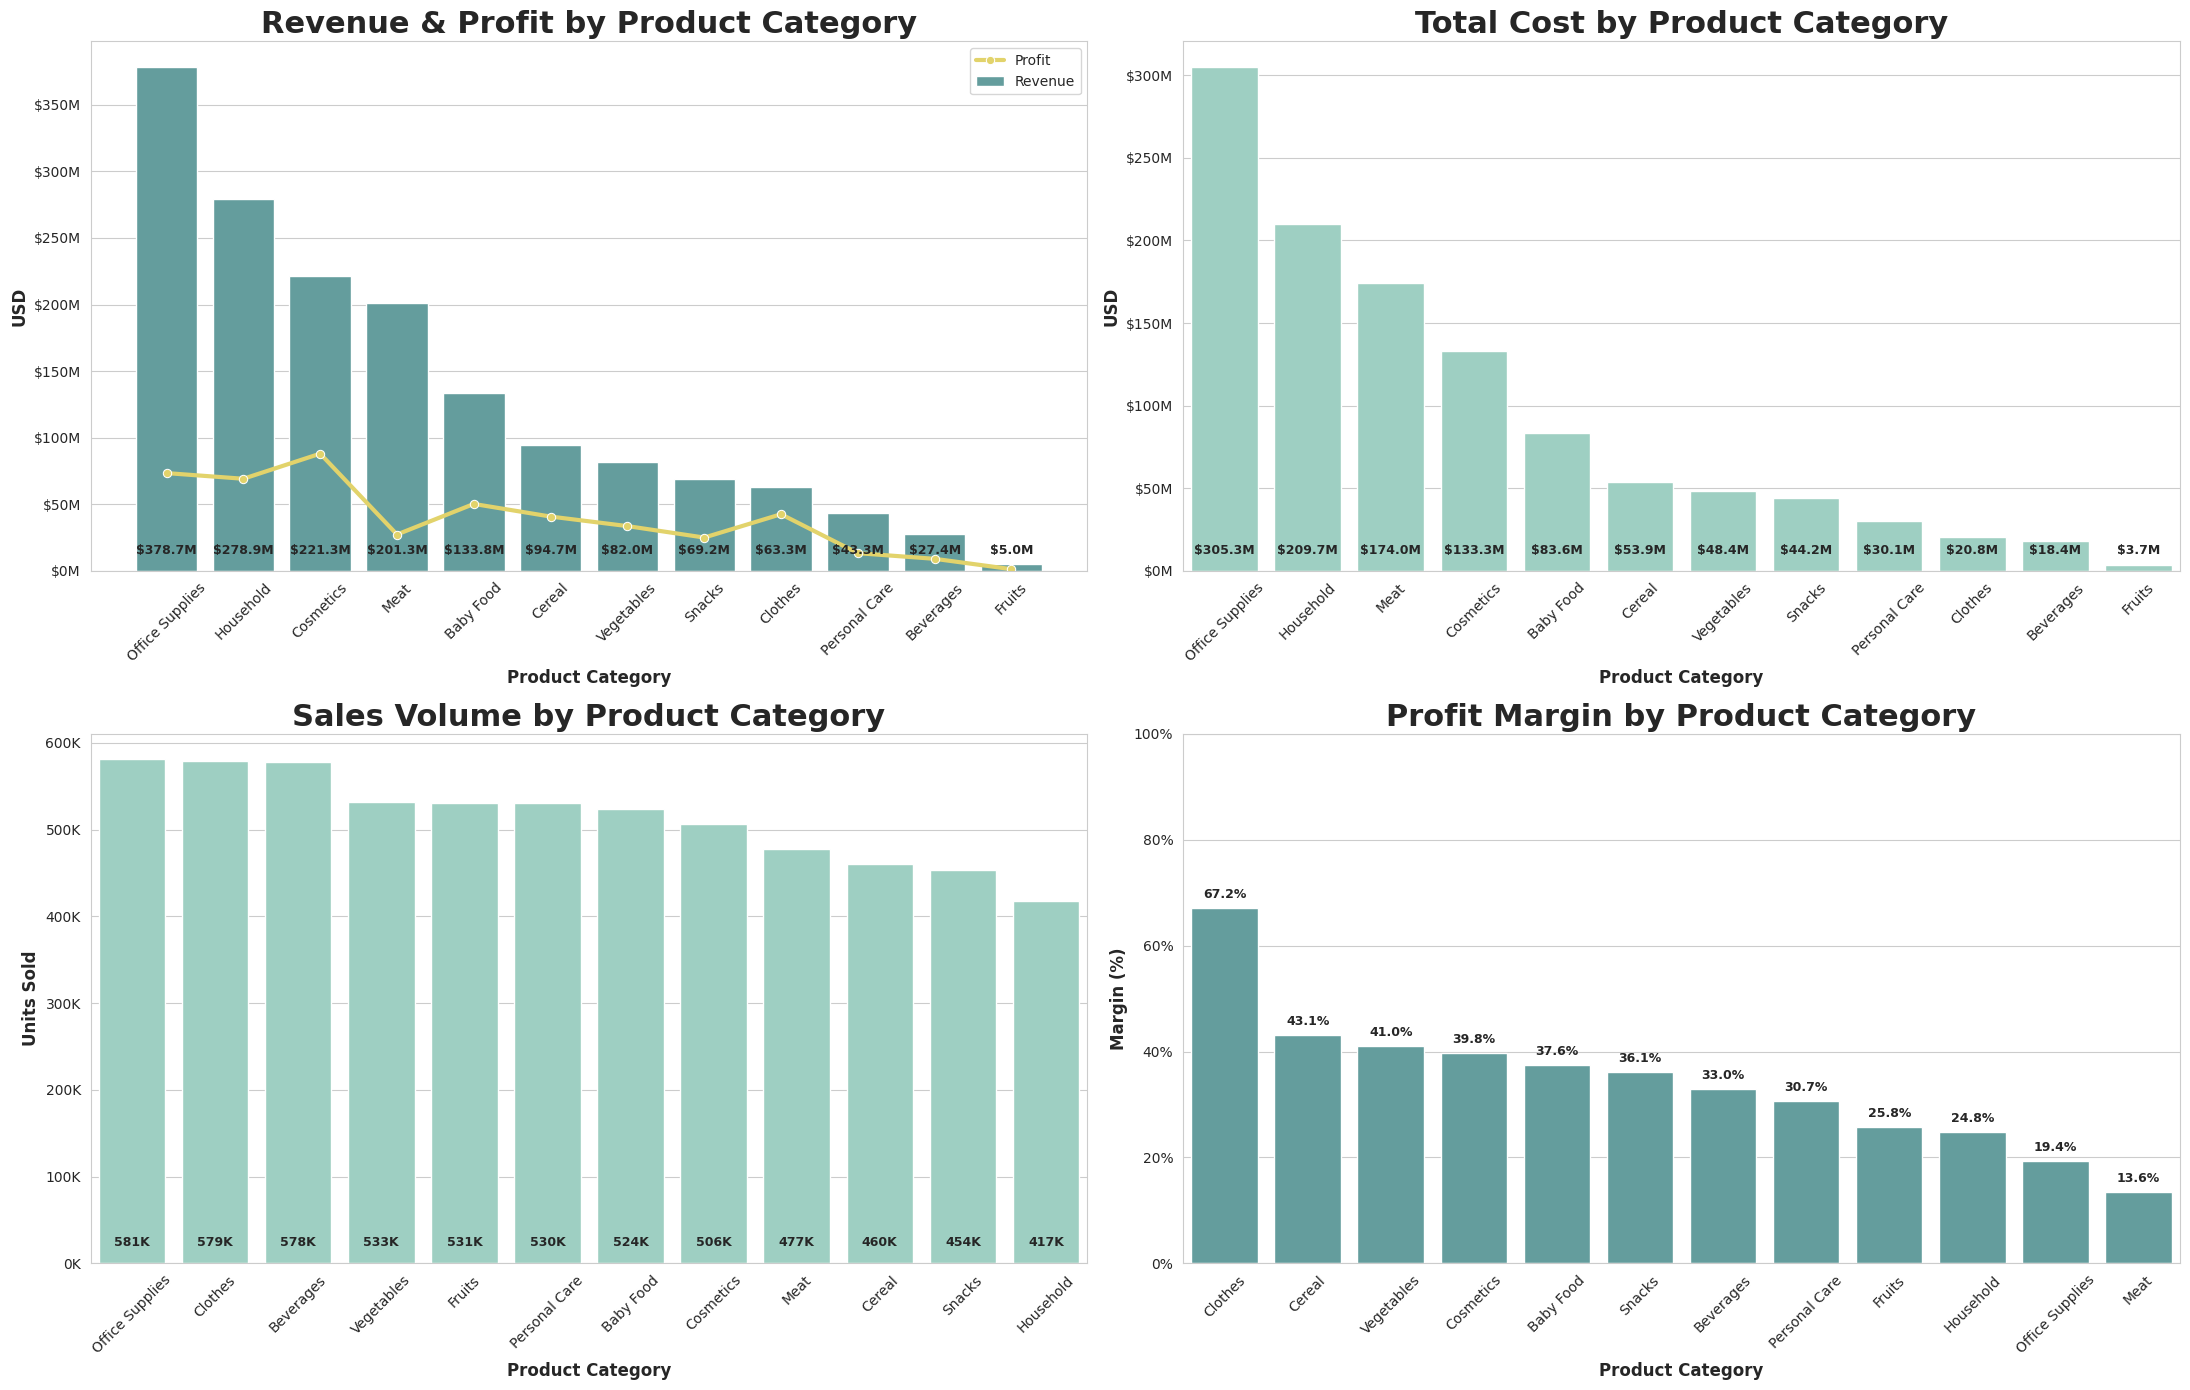

In [41]:
# Dashboard Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.25)

colors = ["#5AA7A7", "#96D7C6", "#BAC94A", "#E2D36B", "#6C8CBF"]

# Graph 1: Revenue & Profit Bar Chart
df_g1 = category_stats.sort_values("revenue", ascending=False)
revenue_bars = sns.barplot(data=df_g1, x="product_category", y="revenue", ax=axes[0,0], color=colors[0], label="Revenue")
sns.lineplot(data=df_g1, x="product_category", y="profit", ax=axes[0,0], color=colors[3], marker="o", linewidth=3, label="Profit")

axes[0,0].set_title("Revenue & Profit by Product Category", fontsize=22, fontweight="bold")
axes[0,0].set_xlabel("Product Category", fontsize=12, fontweight="bold")
axes[0,0].set_ylabel("USD", fontsize=12, fontweight="bold")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M"))
axes[0,0].legend()

# Adding data labels inside the base of the bars
for bar in revenue_bars.patches:
    axes[0,0].annotate(f"${bar.get_height()/1e6:.1f}M",
                   (bar.get_x() + bar.get_width() / 2., 0),
                   ha="center", va="bottom",
                   xytext=(0, 10),
                   textcoords="offset points", fontweight="bold", fontsize=9)

# Graph 2: Total Cost Bar Chart
df_g2 = category_stats.sort_values("total_cost", ascending=False)
cost_bars = sns.barplot(data=df_g2, x="product_category", y="total_cost", ax=axes[0,1], color=colors[1])

axes[0,1].set_title("Total Cost by Product Category", fontsize=22, fontweight="bold")
axes[0,1].set_xlabel("Product Category", fontsize=12, fontweight="bold")
axes[0,1].set_ylabel("USD", fontsize=12, fontweight="bold")
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M"))

# Adding data labels inside the base of the bars
for p in cost_bars.patches:
    axes[0,1].annotate(f"${p.get_height()/1e6:.1f}M",
                   (p.get_x() + p.get_width() / 2., 0),
                   ha="center", va="bottom",
                   xytext=(0, 10),
                   textcoords="offset points", fontweight="bold", fontsize=9)

# Graph 3: Sales Volume (Units Sold) Bar Chart
df_g3 = category_stats.sort_values("units_sold", ascending=False)
sales_bars = sns.barplot(data=df_g3, x="product_category", y="units_sold", ax=axes[1,0], color=colors[1])

axes[1,0].set_title("Sales Volume by Product Category", fontsize=22, fontweight="bold")
axes[1,0].set_xlabel("Product Category", fontsize=12, fontweight="bold")
axes[1,0].set_ylabel("Units Sold", fontsize=12, fontweight="bold")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"{x/1e3:,.0f}K"))

# Adding data labels inside the base of the bars
for b in sales_bars.patches:
    axes[1,0].annotate(f"{b.get_height()/1e3:,.0f}K",
                   (b.get_x() + b.get_width() / 2., 0),
                   ha="center", va="bottom",
                   xytext=(0, 10),
                   textcoords="offset points", fontweight="bold", fontsize=9)

# Graph 4: Profit Margin % Bar Chart
df_g4 = category_stats.sort_values("profit_margin", ascending=False)
margin_bars = sns.barplot(data=df_g4, x="product_category", y="profit_margin", ax=axes[1,1], color=colors[0])

axes[1,1].set_title("Profit Margin by Product Category", fontsize=22, fontweight="bold")
axes[1,1].set_xlabel("Product Category", fontsize=12, fontweight="bold")
axes[1,1].set_ylabel("Margin (%)", fontsize=12, fontweight="bold")
axes[1,1].tick_params(axis="x", rotation=45)

axes[1,1].set_ylim(0, 100)
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())

# Add percentage labels on top of bars
for m in margin_bars.patches:
    axes[1,1].annotate(f"{m.get_height():.1f}%",
                   (m.get_x() + m.get_width() / 2., m.get_height()),
                   ha="center", va="bottom", xytext=(0, 5),
                   textcoords="offset points", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

**Sales Analysis by Product Category**
- **Revenue Leaders & Laggards**: The company’s revenue is primarily driven by the **Office Supplies** (\$378.7M) and **Household** (\$278.9M) categories. **Fruits** generates the lowest revenue at only \$5.0M.
- **Profitability**: Even though it does not have the highest revenue, **Cosmetics** is the most profitable category, yielding **\$88.0M** in profit. **Fruits** is the least profitable, contributing only \$1.3M to the final result.
- **Volume**: Looking at the number of items sold, **Office Supplies** leads with 581K units, followed closely by **Clothes** (579K) and **Beverages** (578K).
- **Total Cost**: The highest investment is tied up in **Office Supplies**, with total costs reaching \$305.3M. This explains why it has high revenue but lower profit compared to other categories.
- **ROI**: **Clothes** is the most efficient category with a high profit margin of **67.2%**. In contrast, **Meat** (13.6%) and **Office Supplies** (19.4%) have the lowest margins, meaning their costs are very high compared to their selling prices.

####**3.4. Geographic Sales Analysis**

In [42]:
# Region Data
region_profit = df.groupby("region")["profit"].sum()

# Sub-Region Data
sub_region_stats = df.groupby("sub-region").agg({
    "profit": "sum",
    "order_id": "nunique",
    "units_sold": "sum"
}).sort_values("profit", ascending=False).reset_index()

sub_region_stats["units_per_order"] = sub_region_stats["units_sold"] / sub_region_stats["order_id"]

# Top 10 Countries by Profit
country_stats = df.groupby("country")["profit"].sum().sort_values(ascending=False).head(10).reset_index()

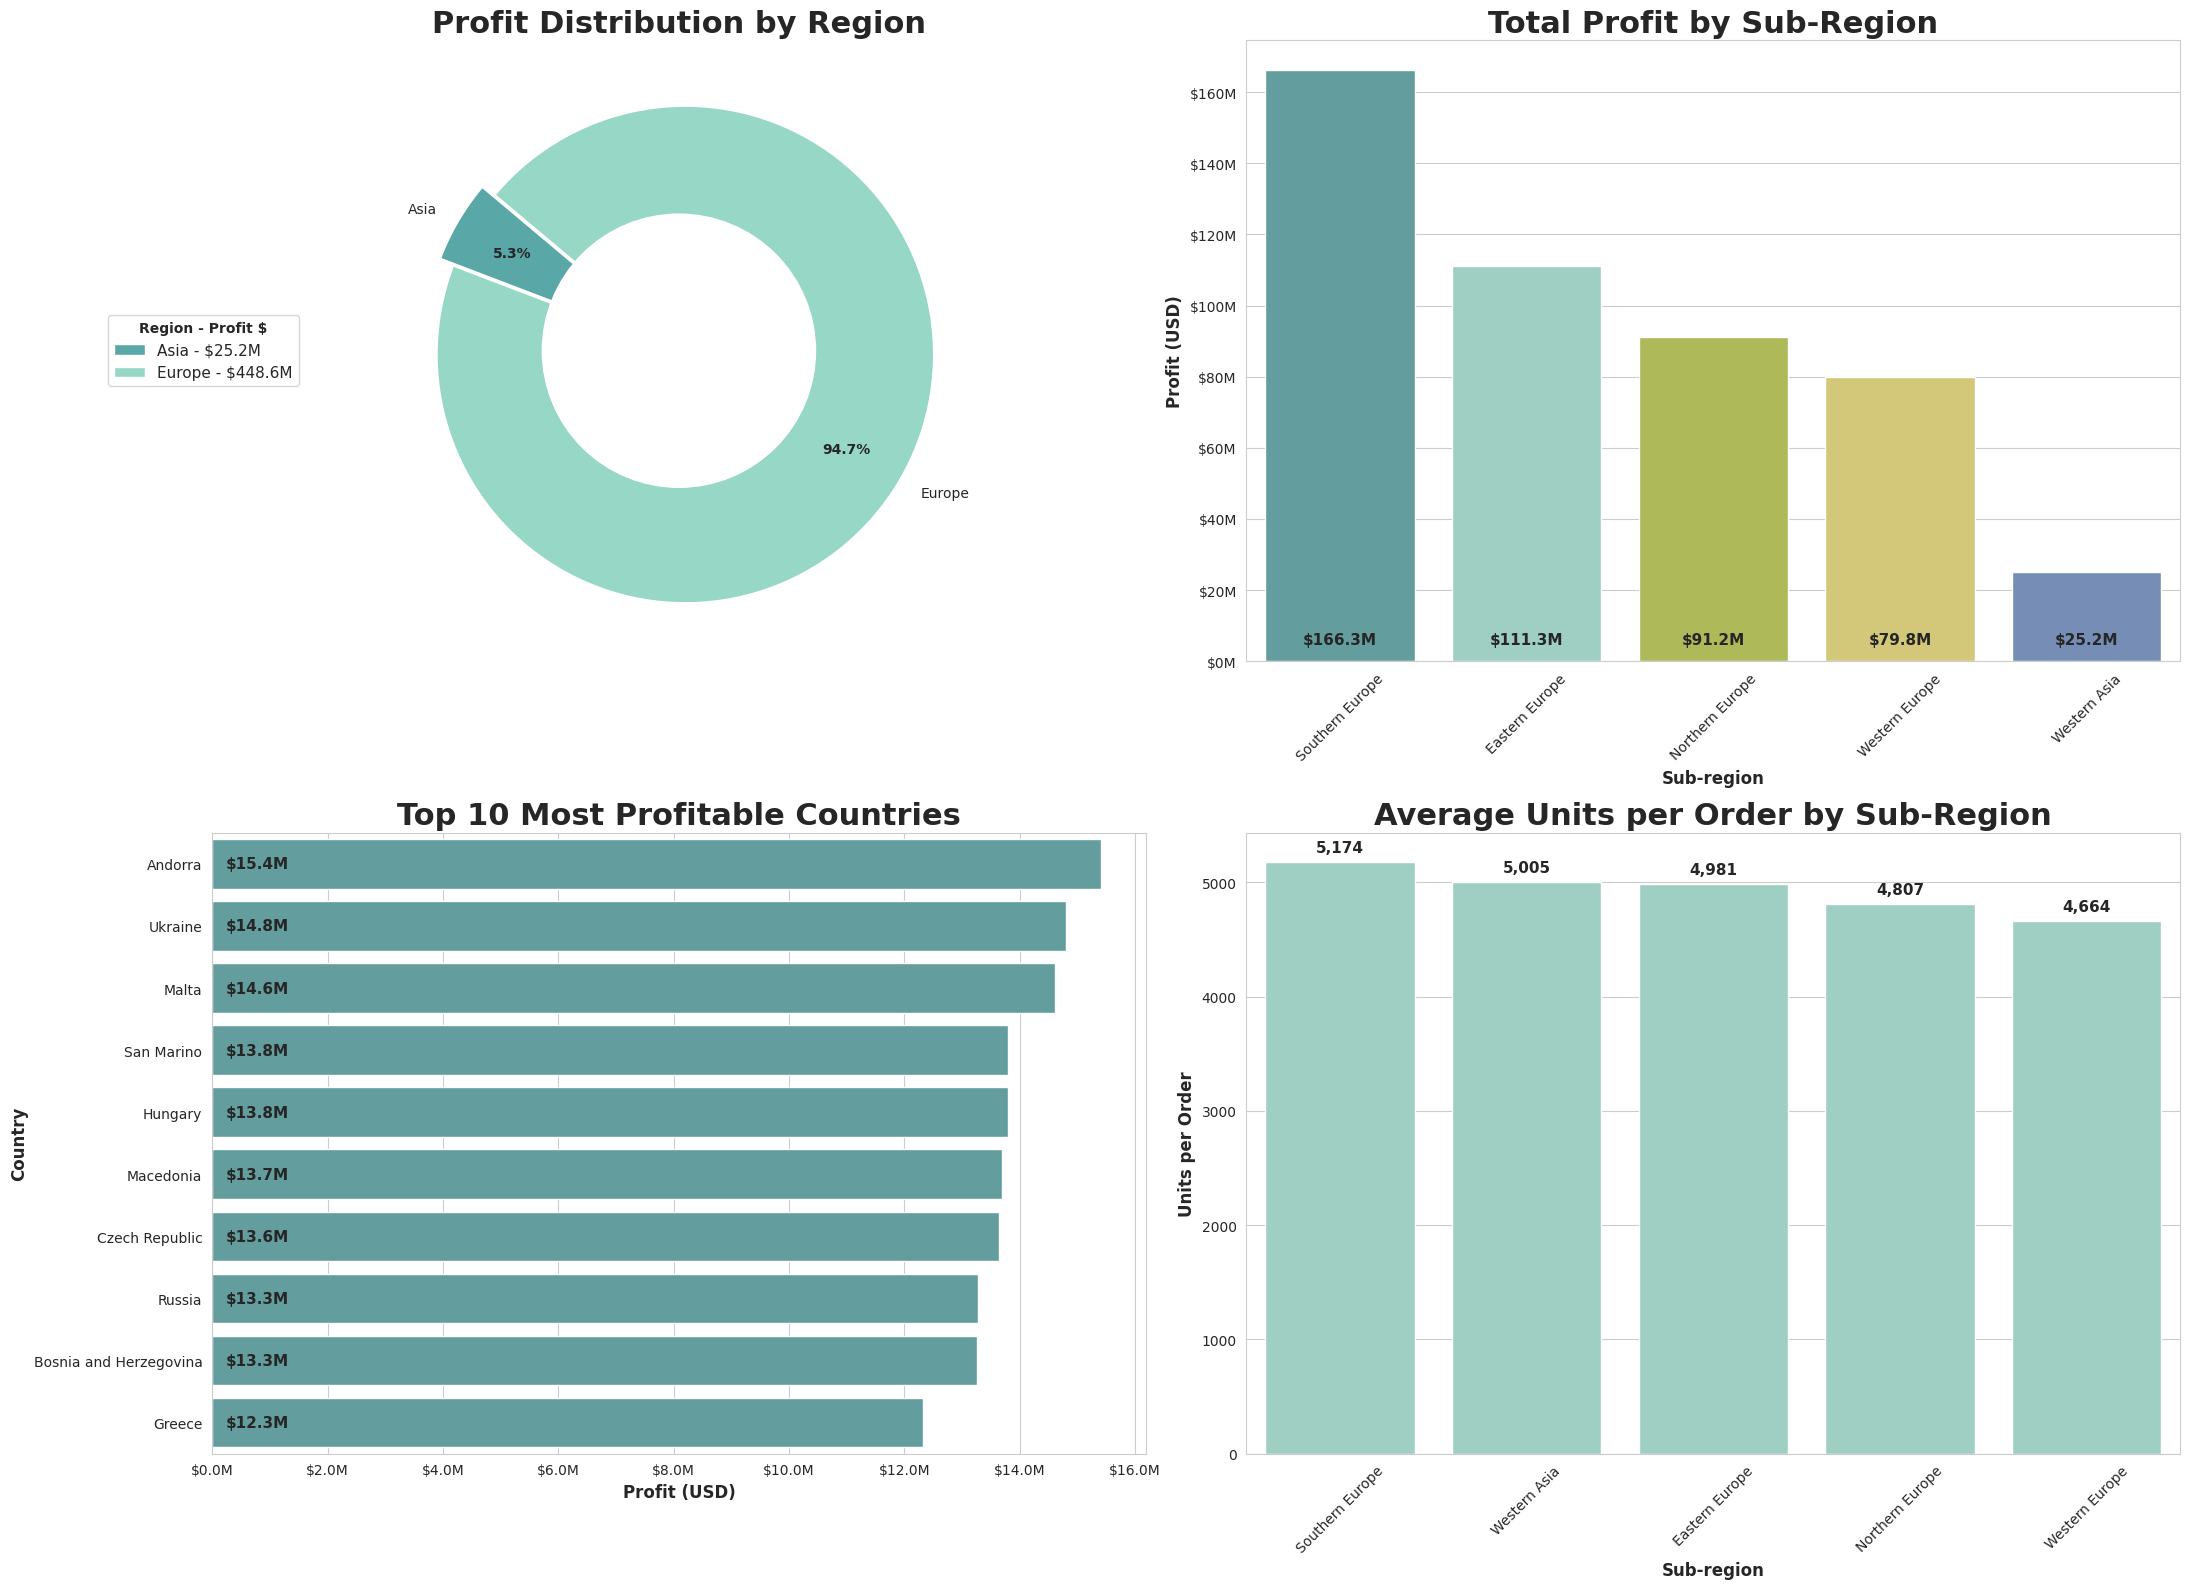

In [43]:
# Dashboard Visualization
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.25)

# Graph 1: Profit by Region Donut Chart
wedges, texts, autotexts = axes[0,0].pie(
    region_profit,
    labels=region_profit.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette(colors),
    pctdistance=0.75,
    explode=[0.03] * len(region_profit))
centre_circle = plt.Circle((0,0), 0.55, fc="white")
plt.setp(autotexts, size=10, weight="bold")

axes[0,0].add_artist(centre_circle)
axes[0,0].set_title("Profit Distribution by Region", fontsize=22, fontweight="bold")

# Adding the legend
legend_labels = [f"{region} - ${val/1e6:.1f}M" for region, val in region_profit.items()]
leg = axes[0,0].legend(
    wedges,
    legend_labels,
    title="Region - Profit $",
    loc="center right",
    bbox_to_anchor=(-0.1, 0.5),
    fontsize=11)
leg.get_title().set_weight("bold")

# Graph 2: Profit by Sub-Region Bar Chart
sr_bars = sns.barplot(data=sub_region_stats, x="sub-region", y="profit", hue="sub-region", ax=axes[0,1], palette=colors)
axes[0,1].set_title("Total Profit by Sub-Region", fontsize=22, fontweight="bold")
axes[0,1].set_xlabel("Sub-region", fontsize=12, fontweight="bold")
axes[0,1].set_ylabel("Profit (USD)", fontsize=12, fontweight="bold")
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M"))

# Adding data labels inside the base of the bars
for p in sr_bars.patches:
    axes[0,1].annotate(f"${p.get_height()/1e6:.1f}M",
                   (p.get_x() + p.get_width() / 2., 0),
                   ha="center", va="bottom",
                   xytext=(0, 10),
                   textcoords="offset points", fontweight="bold", fontsize=11)

# Graph 3: Top 10 Countries by Profit Bar Chart
country_bars = sns.barplot(data=country_stats, x="profit", y="country", ax=axes[1,0], color=colors[0])
axes[1,0].set_title("Top 10 Most Profitable Countries", fontsize=22, fontweight="bold")
axes[1,0].set_xlabel("Profit (USD)", fontsize=12, fontweight="bold")
axes[1,0].set_ylabel("Country", fontsize=12, fontweight="bold")
axes[1,0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))

# Adding data labels inside the base of the bars
for c in country_bars.patches:
  value = c.get_width()
  axes[1,0].annotate(f"${value/1e6:.1f}M",
                   (0, c.get_y() + c.get_height() / 2.),
                   ha="left", va="center",
                   xytext=(10, 0),
                   textcoords="offset points", fontweight="bold", fontsize=11)

# Graph 4: Popularity by Sub-Region Bar Chart
df_pop = sub_region_stats.sort_values("units_per_order", ascending=False)
pop_bars = sns.barplot(data=df_pop, x="sub-region", y="units_per_order", ax=axes[1,1], color=colors[1])

axes[1,1].set_title("Average Units per Order by Sub-Region", fontsize=22, fontweight="bold")
axes[1,1].set_xlabel("Sub-region", fontsize=12, fontweight="bold")
axes[1,1].set_ylabel("Units per Order", fontsize=12, fontweight="bold")
axes[1,1].tick_params(axis="x", rotation=45)

# Add labels on top of bars
for p in pop_bars.patches:
    axes[1,1].annotate(f"{p.get_height():,.0f}",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha="center", va="bottom", xytext=(0, 5),
                   textcoords="offset points", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()

**Geographic Sales Analysis**
- **Regional Performance**: **Europe** is the primary driver of the business, accounting for **94.7%** (\$448.6M) of total profit, while **Asia** contributes **5.3%** (\$25.2M).
- **Sub-Regional Performance**: Within Europe, **Southern Europe** leads with \$166.3M in profit, followed by **Eastern Europe** (\$111.3M). In Asia, the **Western Asia** sub-region generated \$25.2M.
- **Top Countries**: **Andorra** is the most profitable country (\$15.4M), followed by **Ukraine** (\$14.8M) and **Malta** (\$14.6M).
- **Units per Order**: The average units per order remain high across all sub-regions, staying around 4,600 to 5,200 units. **Southern Europe** has the highest bulk-purchase rate with 5,174 units per order.

####**3.5. Sales Channel**

In [44]:
# Profit by Channel
channel_profit = df.groupby("sales_channel")["profit"].sum().sort_values(ascending=False)

# Orders by Year and Channel
df["year"] = df["order_date"].dt.year
yearly_channel = df.groupby(["year", "sales_channel"])["order_id"].nunique().reset_index()

# Top 7 Countries Online
top_online = df[df["sales_channel"] == "Online"].groupby(
    "country")["order_id"].nunique().sort_values(ascending=False).head(7).reset_index()

# Top 7 Countries Offline
top_offline = df[df["sales_channel"] == "Offline"].groupby(
    "country")["order_id"].nunique().sort_values(ascending=False).head(7).reset_index()

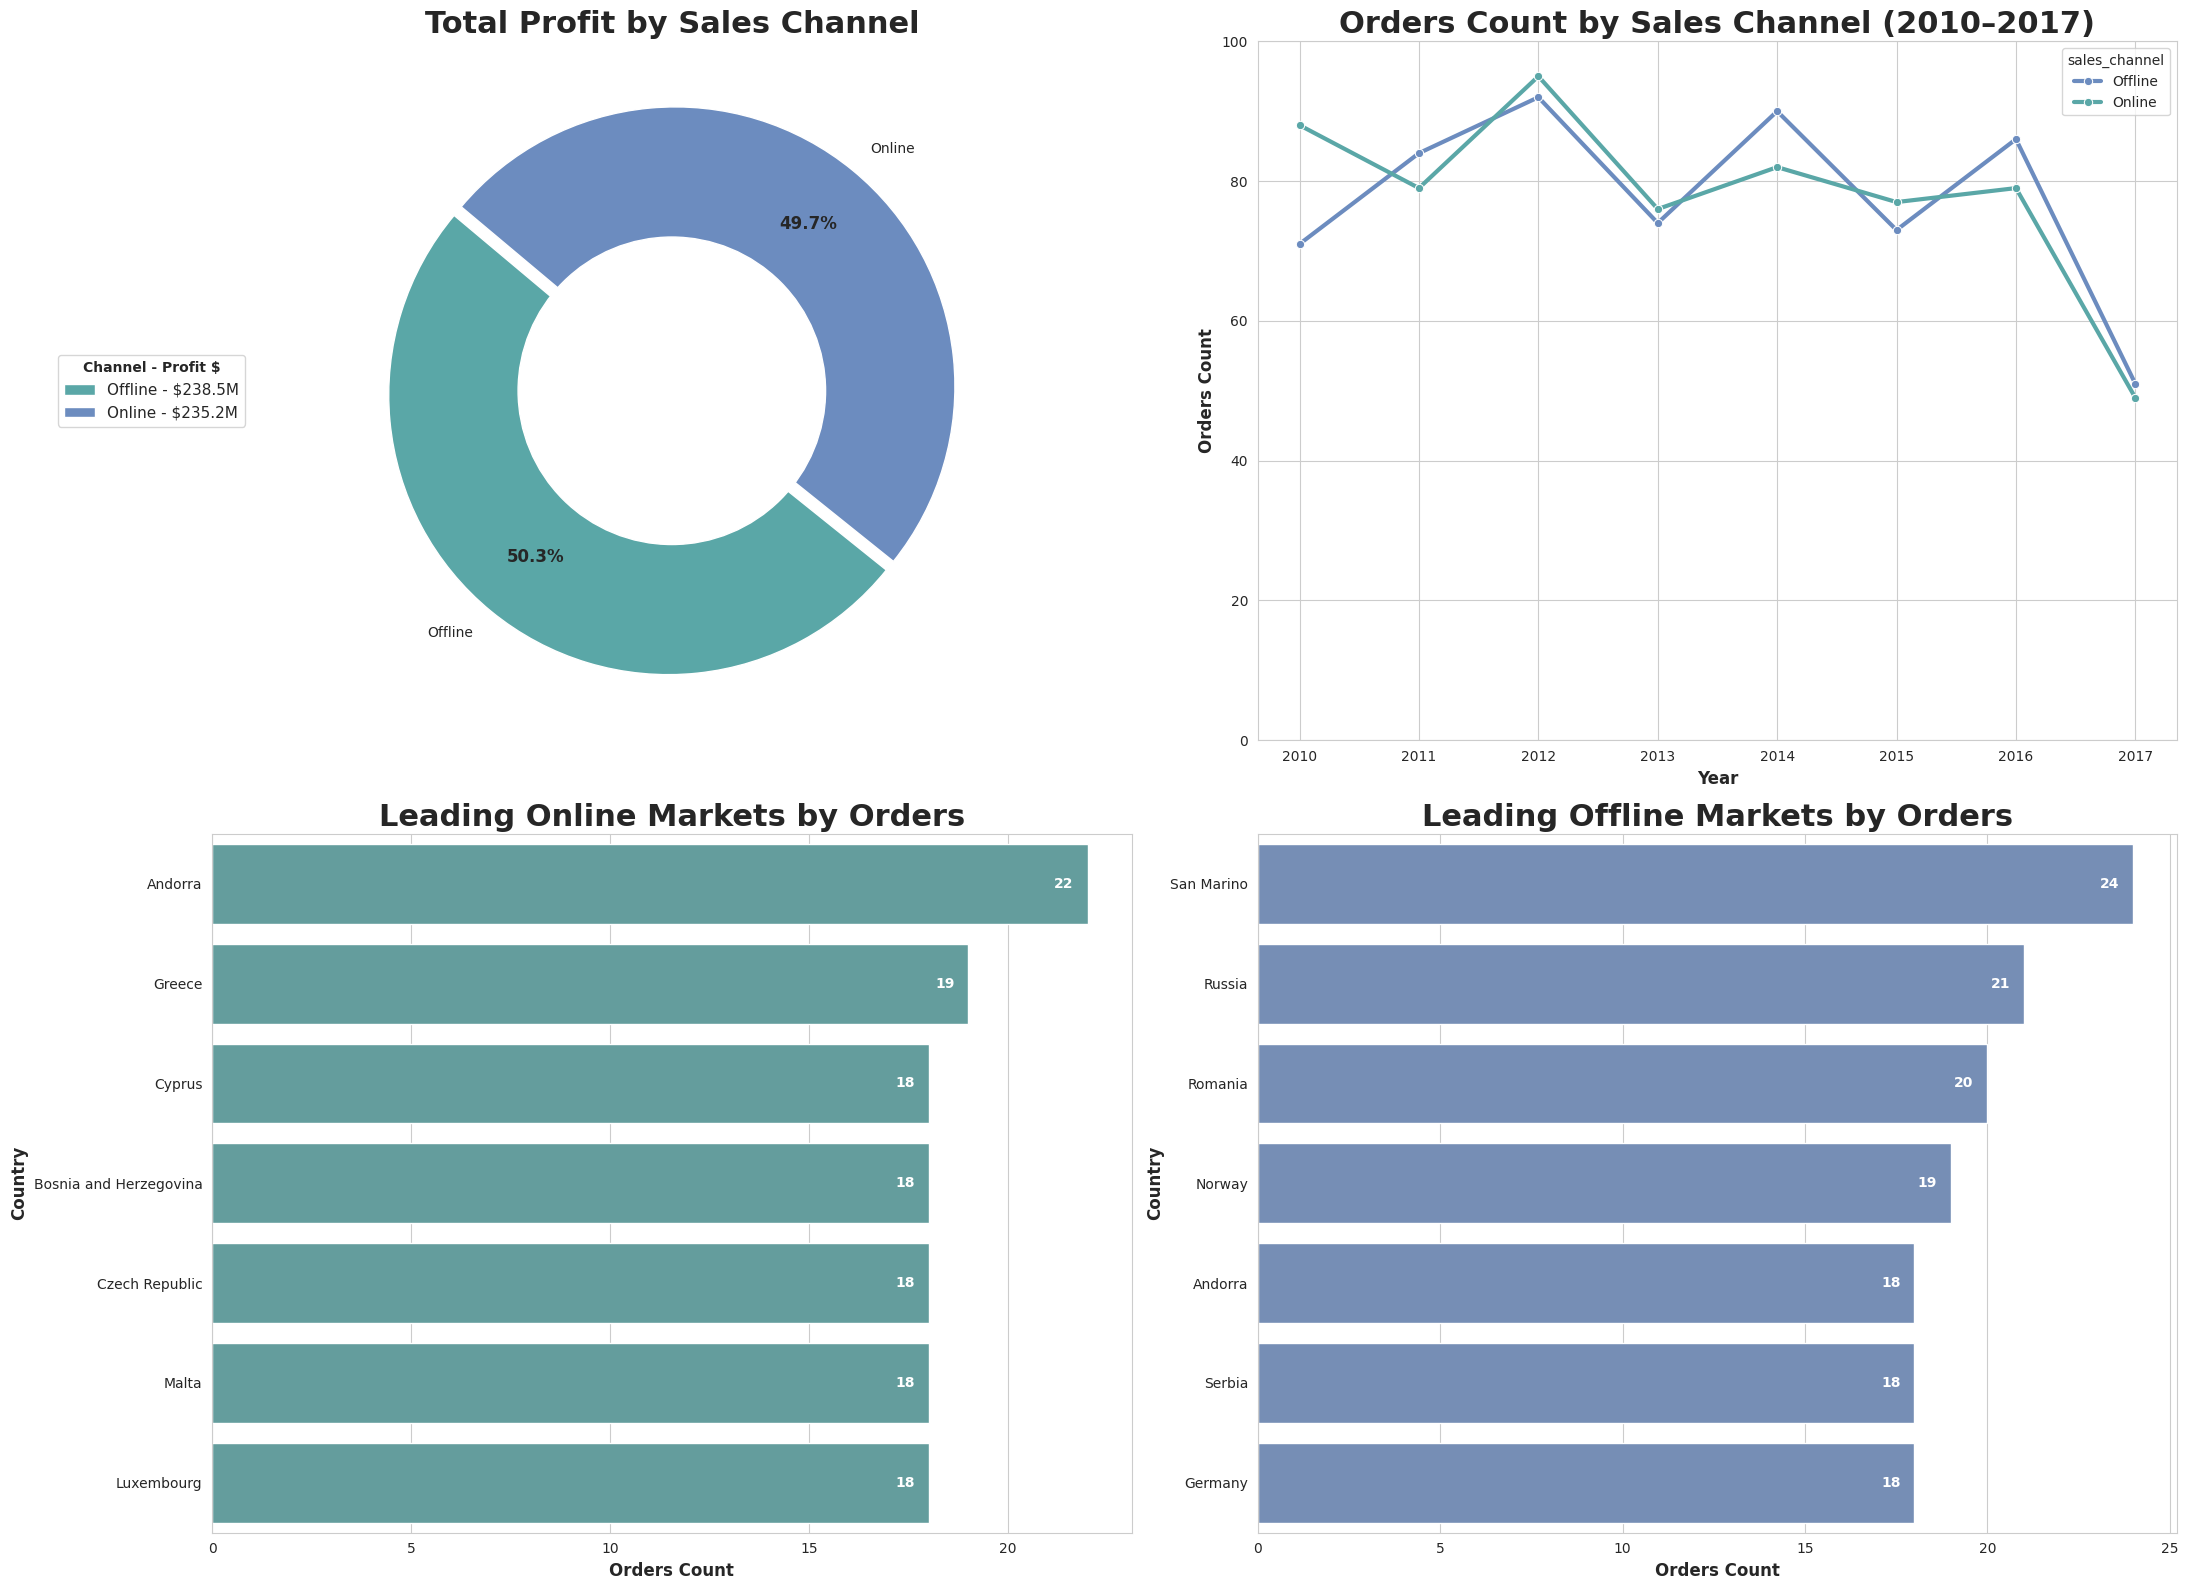

In [45]:
# Dashboard Visualization
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
color_online = colors[0]
color_offline = colors[4]

# Graph 1: Profit Distribution by Channel Donut Chart
wedges, texts, autotexts = axes[0,0].pie(
    channel_profit,
    labels=channel_profit.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=[color_online, color_offline],
    pctdistance=0.75,
    explode=[0.02, 0.02])
axes[0,0].add_artist(plt.Circle((0,0), 0.55, fc="white"))
plt.setp(autotexts, size=12, weight="bold")

# Legend with Profit values
legend_labels = [f"{channel} - ${val/1e6:.1f}M" for channel, val in channel_profit.items()]
leg = axes[0,0].legend(wedges, legend_labels,
                       title="Channel - Profit $",
                       loc="center right",
                       bbox_to_anchor=(-0.1, 0.5), fontsize=11)
leg.get_title().set_weight("bold")

axes[0,0].set_title("Total Profit by Sales Channel", fontsize=22, fontweight="bold")

# Graph 2: Orders Count by Sales Channel Line Chart
sns.lineplot(data=yearly_channel, x="year", y="order_id", hue="sales_channel",
             ax=axes[0,1], palette=[color_offline, color_online], marker="o", linewidth=3)
axes[0,1].set_title("Orders Count by Sales Channel (2010–2017)", fontsize=22, fontweight="bold")
axes[0,1].set_xlabel("Year", fontsize=12, fontweight="bold")
axes[0,1].set_ylabel("Orders Count", fontsize=12, fontweight="bold")
axes[0,1].set_ylim(0, 100)

# Graph 3: Leading Online Markets Bar Chart
on_bars = sns.barplot(data=top_online, x="order_id", y="country", ax=axes[1,0], color=color_online)
axes[1,0].set_title("Leading Online Markets by Orders", fontsize=22, fontweight="bold")
axes[1,0].set_xlabel("Orders Count", fontsize=12, fontweight="bold")
axes[1,0].set_ylabel("Country", fontsize=12, fontweight="bold")

# Adding data labels
for p in on_bars.patches:
    axes[1,0].annotate(f"{int(p.get_width())}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha="right", va="center", xytext=(-10, 0),
                       textcoords="offset points", color="white", fontweight="bold")

# Graph 4: Leading Offline Markets Bar Chart
off_bars = sns.barplot(data=top_offline, x="order_id", y="country", ax=axes[1,1], color=color_offline)
axes[1,1].set_title("Leading Offline Markets by Orders", fontsize=22, fontweight="bold")
axes[1,1].set_xlabel("Orders Count", fontsize=12, fontweight="bold")
axes[1,1].set_ylabel("Country", fontsize=12, fontweight="bold")

# Adding data labels
for p in off_bars.patches:
    axes[1,1].annotate(f"{int(p.get_width())}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha="right", va="center", xytext=(-10, 0),
                       textcoords="offset points", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

**Sales Channel Performance Analysis**
- The business maintains a near-perfect balance between its sales platforms. **Offline** channels contribute **50.3%** (\$238.5M) of total profit, while **Online** channels follow closely with **49.7%** (\$235.2M). This indicates that the company is equally successful in digital and traditional markets.
- **Order Dynamics (2010-2017)**: The number of orders per channel was between 70 and 95 orders annually. There is a significant drop in 2017, which likely indicates the data for that year is only partial.
- **Online Leaders**: **Andorra** is the strongest online market with 22 orders, followed by **Greece** with 19.
- **Offline Leaders**: **San Marino** is the top offline market with 24 orders, followed by **Romania** (20).
- The business model is stable. No single channel dominates the other, providing the company with a diversified risk profile across its global operations.

####**3.6. Logistics and Shipping**

In [46]:
# Ship Interval
df["ship_interval"] = (df["ship_date"] - df["order_date"]).dt.days

# By Product Category
cat_ship = df.groupby("product_category")["ship_interval"].mean().sort_values(ascending=False).reset_index()

# By Sub-Region
sub_region_ship = df.groupby("sub-region")["ship_interval"].mean().sort_values(ascending=False).reset_index()

# By Country (Top 10 with longest delays)
country_ship = df.groupby("country")["ship_interval"].mean().sort_values(ascending=False).head(10).reset_index()

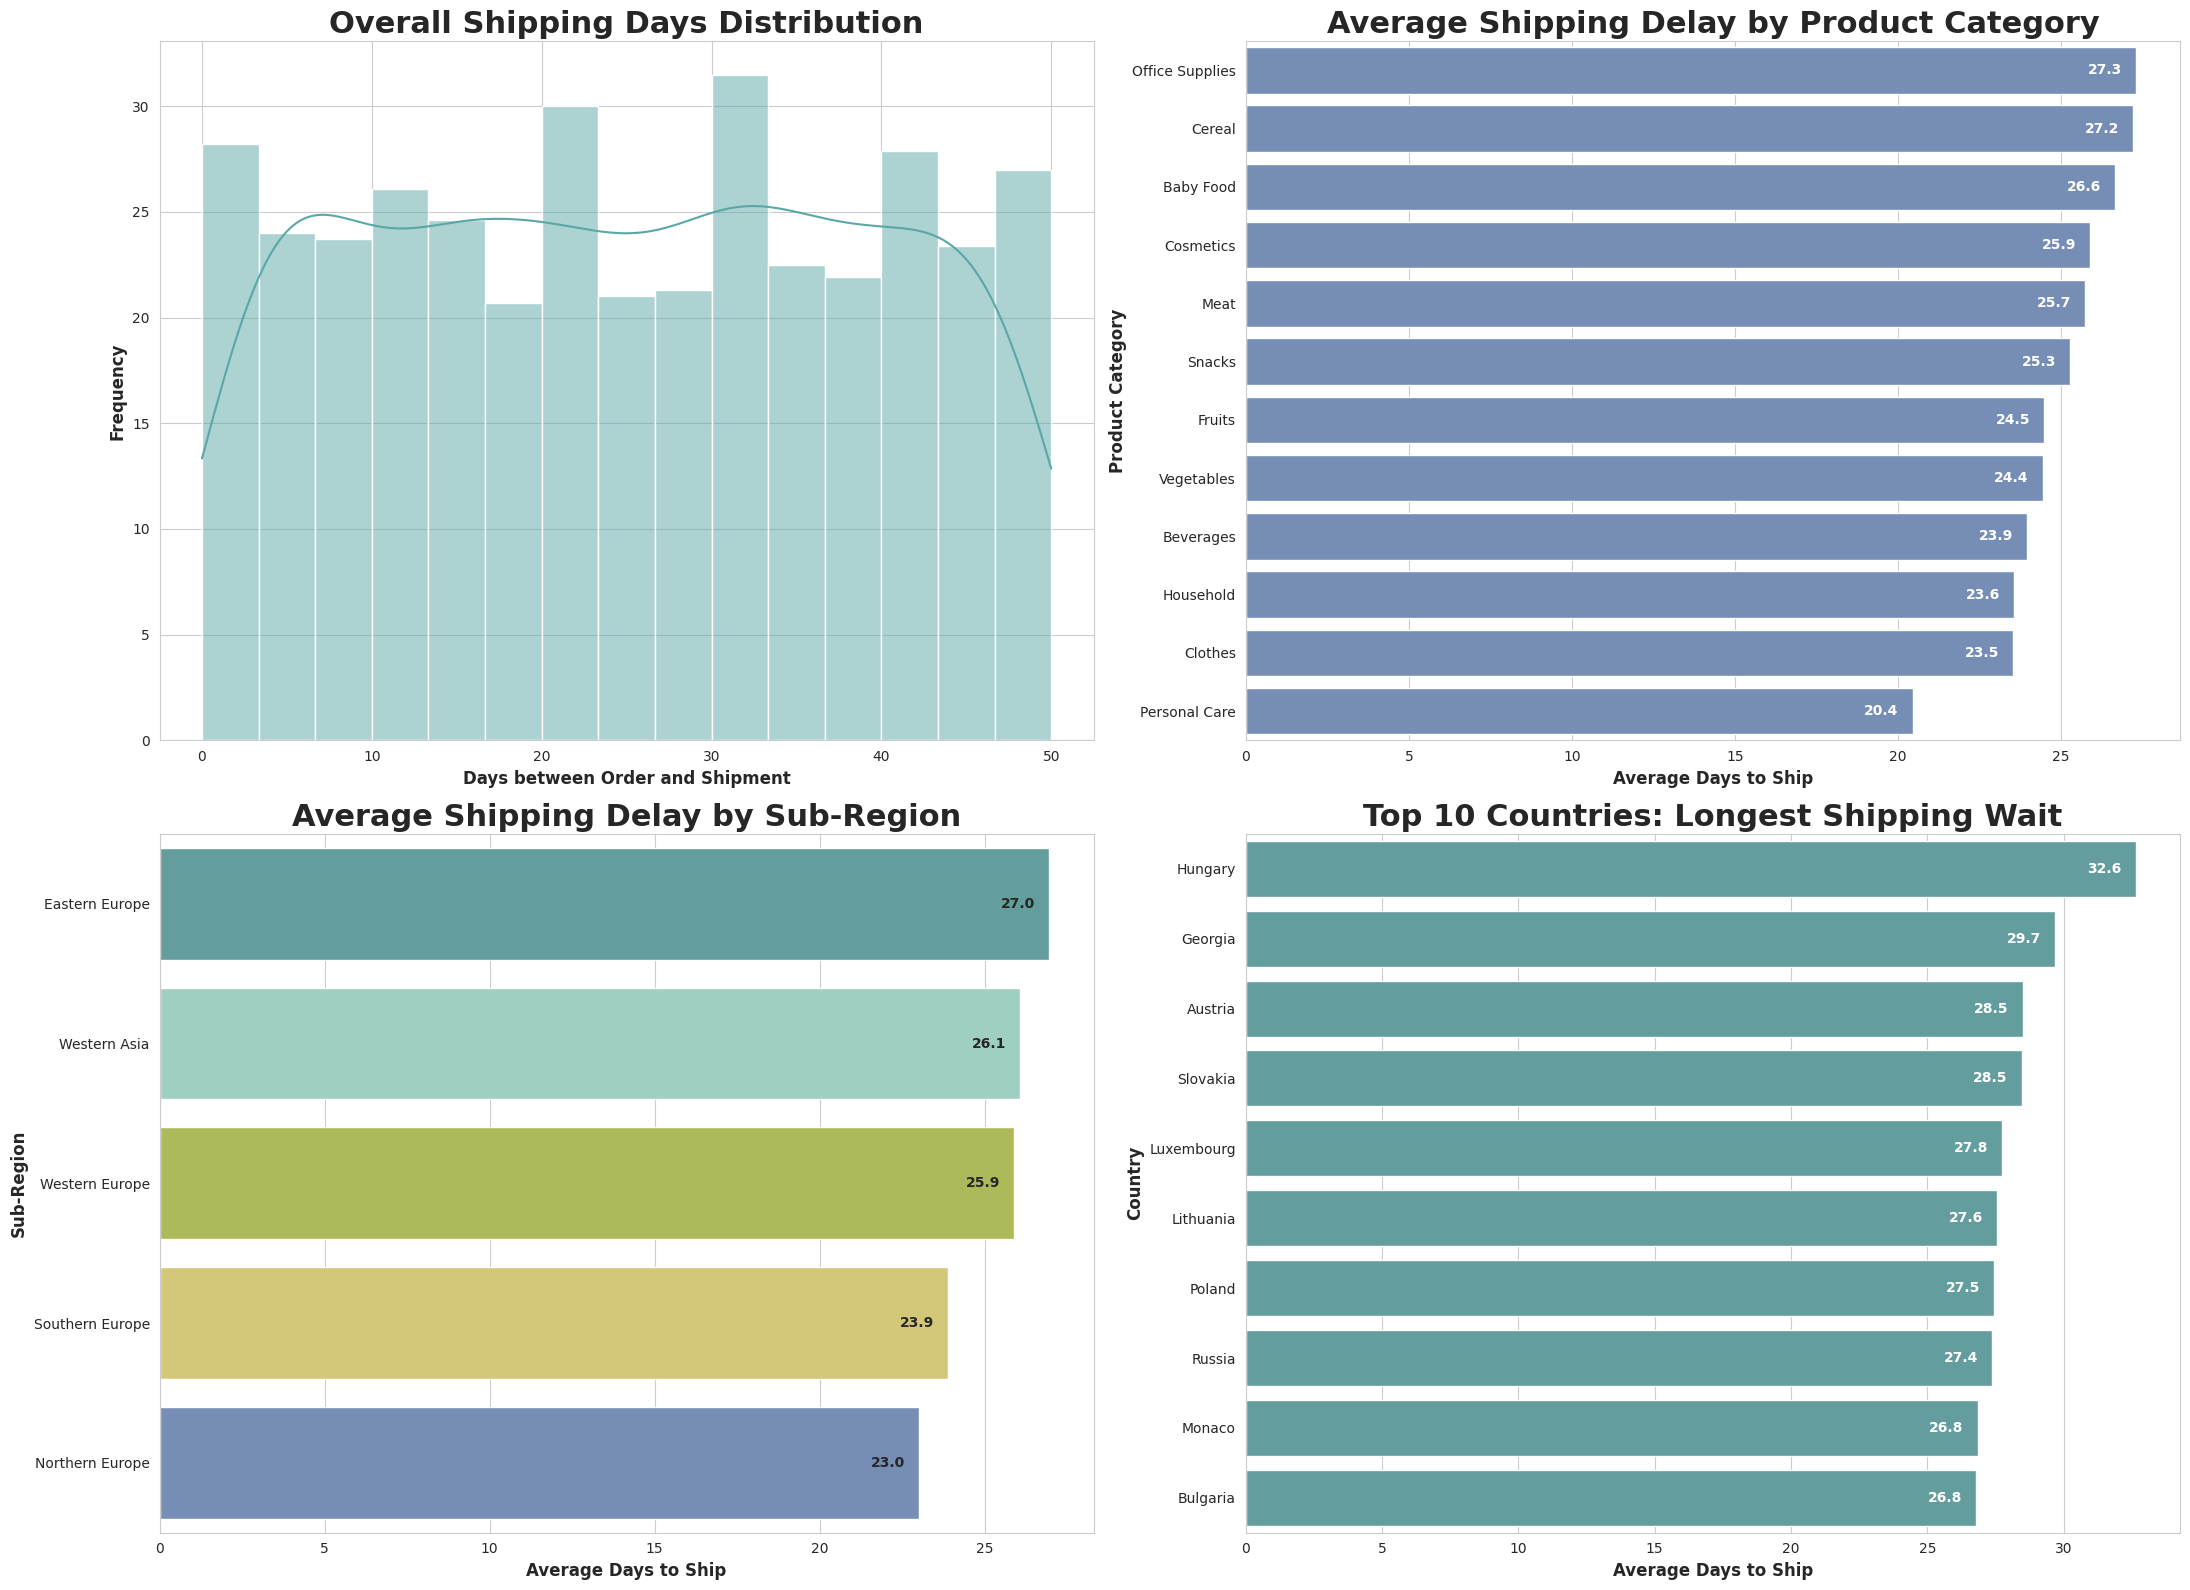

In [47]:
# Dashboard Visualization
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Graph 1: Distribution of Shipping Days Histogram
sns.histplot(df["ship_interval"], stat="frequency", bins=15, kde=True, ax=axes[0,0], color=colors[0], edgecolor="white")
axes[0,0].set_title("Overall Shipping Days Distribution", fontsize=22, fontweight="bold")
axes[0,0].set_xlabel("Days between Order and Shipment", fontsize=12, fontweight="bold")
axes[0,0].set_ylabel("Frequency", fontsize=12, fontweight="bold")

# Graph 2: Shipping Delay by Product Category Bar Chart
ship_bars = sns.barplot(data=cat_ship, x="ship_interval", y="product_category", ax=axes[0,1], color=colors[4])
axes[0,1].set_title("Average Shipping Delay by Product Category", fontsize=22, fontweight="bold")
axes[0,1].set_xlabel("Average Days to Ship", fontsize=12, fontweight="bold")
axes[0,1].set_ylabel("Product Category", fontsize=12, fontweight="bold")

# Adding data labels
for p in ship_bars.patches:
    axes[0,1].annotate(f"{p.get_width():.1f}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha="right", va="center", xytext=(-10, 0),
                       textcoords="offset points", color="white", fontweight="bold")

# Graph 3: Shipping Delay by Sub-Region Bar Chart
ship_reg_bars = sns.barplot(data=sub_region_ship, x="ship_interval", y="sub-region", hue="sub-region", ax=axes[1,0], palette=colors)
axes[1,0].set_title("Average Shipping Delay by Sub-Region", fontsize=22, fontweight="bold")
axes[1,0].set_xlabel("Average Days to Ship", fontsize=12, fontweight="bold")
axes[1,0].set_ylabel("Sub-Region", fontsize=12, fontweight="bold")

# Adding data labels
for p in ship_reg_bars.patches:
    axes[1,0].annotate(f"{p.get_width():.1f}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha="right", va="center", xytext=(-10, 0),
                       textcoords="offset points", fontweight="bold")

# Graph 4: Top 10 Countries with Longest Shipping Time Bar Chart
ship_cn_bars = sns.barplot(data=country_ship, x="ship_interval", y="country", ax=axes[1,1], color=colors[0])
axes[1,1].set_title("Top 10 Countries: Longest Shipping Wait", fontsize=22, fontweight="bold")
axes[1,1].set_xlabel("Average Days to Ship", fontsize=12, fontweight="bold")
axes[1,1].set_ylabel("Country", fontsize=12, fontweight="bold")

# Adding data labels
for p in ship_cn_bars.patches:
    axes[1,1].annotate(f"{p.get_width():.1f}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha="right", va="center", xytext=(-10, 0),
                       textcoords="offset points", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

**Logistics and Shipping Analysis**

- The **shipping time** is widely distributed between **0 and 50 days**. There is no single "peak," which shows that shipping speeds vary significantly across different orders.
- **By Product Category**: The longest average shipping delays are found in **Office Supplies** (27.3 days) and **Cereal** (27.2 days). **Personal Care** is the most efficient category, with the fastest average shipping time of 20.4 days.
- **By Region**: **Eastern Europe** is the slowest sub-region, averaging 27.0 days per shipment. **Western Asia** follows closely with an average delay of 26.1 days. The most efficient logistics are found in **Southern Europe** (23.9 days) and **Northern Europe** (23.0 days).
- **By Country**: **Hungary** has the longest wait time of any country, averaging 32.6 days. Other countries with significant delays include **Georgia** (29.7 days), **Austria** (28.5 days), and **Slovakia** (28.5 days). All countries in the top 10 list have an average shipping delay of at least 26.8 days.

####**3.7. Shipping Interval vs Profit**

In [48]:
# Create bins for shipping time segments (0–7, 8–14, 15–21, 22+ days)
bins = [0, 7, 14, 21, df["ship_interval"].max()]
labels = ["0–7 days", "8–14 days", "15–21 days", "22+ days"]
df["ship_bin"] = pd.cut(df["ship_interval"], bins=bins, labels=labels, include_lowest=True)
df["profit_margin"] = df["profit"] / df["revenue"] * 100

# Aggregate stats by shipping time bins
bin_stats = df.groupby("ship_bin", observed=True).agg({
    "profit": "mean",
    "profit_margin": "mean",
    "order_id": "nunique"
}).reset_index()

# Analyze logistics performance by Order Priority
priority_ship = df.groupby("priority").agg({
    "ship_interval": "mean",
    "profit": "mean",
    "profit_margin": "mean",
    "order_id": "nunique"
}).reset_index().sort_values("ship_interval")

# Calculate Pearson correlation
corr_value = df["ship_interval"].corr(df["profit"])
print(f"Pearson correlation (ship_interval vs profit): {corr_value:.4f}")

Pearson correlation (ship_interval vs profit): 0.0607


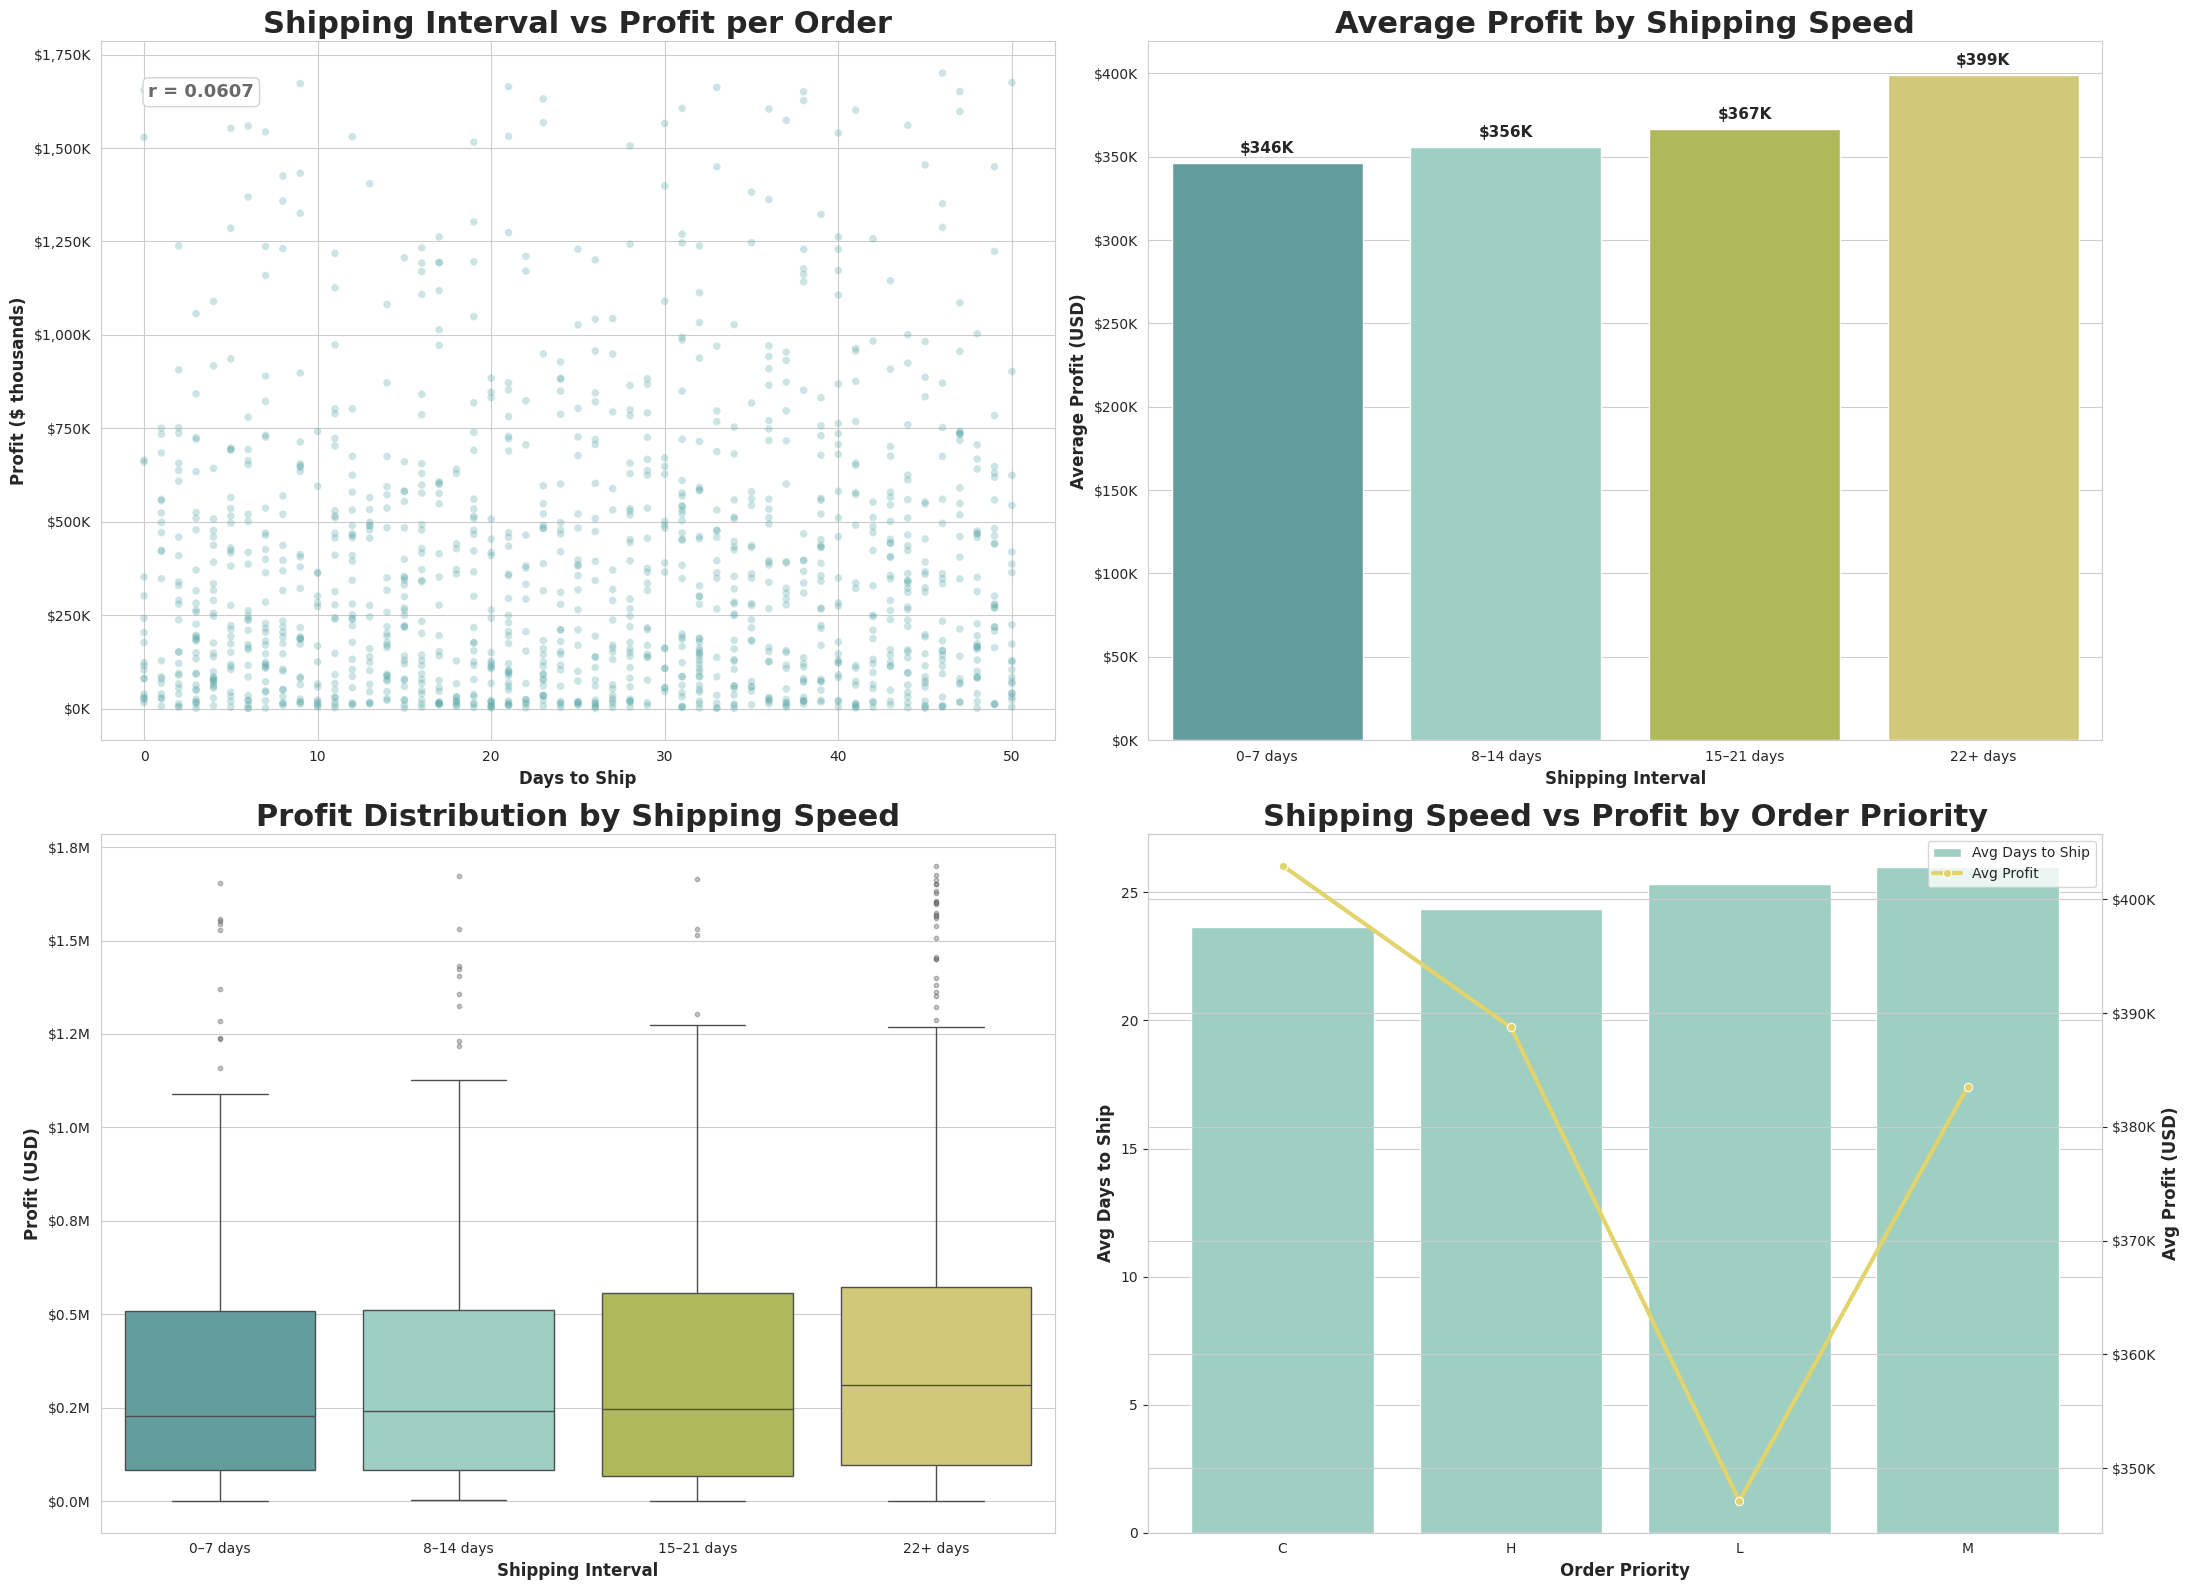

In [49]:
# Dashboard Visualization
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Graph 1: Ship_interval vs Profit Scatter Plot
axes[0,0].scatter(df["ship_interval"], df["profit"] / 1e3,
                  alpha=0.3, color=colors[0], edgecolors="none", s=30)
axes[0,0].set_title("Shipping Interval vs Profit per Order", fontsize=22, fontweight="bold")
axes[0,0].set_xlabel("Days to Ship", fontsize=12, fontweight="bold")
axes[0,0].set_ylabel("Profit ($ thousands)", fontsize=12, fontweight="bold")
axes[0,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x:,.0f}K"))

# Add correlation annotation box
axes[0,0].annotate(f"r = {corr_value:.4f}", xy=(0.05, 0.92),
                   xycoords="axes fraction", fontsize=13, fontweight="bold",
                   color="dimgray",
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray"))

# Graph 2: Average Profit by Ship Bin Bar chart
bin_bars = sns.barplot(data=bin_stats, x="ship_bin", y="profit",
                       hue="ship_bin", ax=axes[0,1], palette=colors[:4])
axes[0,1].set_title("Average Profit by Shipping Speed", fontsize=22, fontweight="bold")
axes[0,1].set_xlabel("Shipping Interval", fontsize=12, fontweight="bold")
axes[0,1].set_ylabel("Average Profit (USD)", fontsize=12, fontweight="bold")
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e3:,.0f}K"))

# Add value labels on top of bars
for p in bin_bars.patches:
    axes[0,1].annotate(f"${p.get_height()/1e3:,.0f}K",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha="center", va="bottom", xytext=(0, 5),
                       textcoords="offset points", fontweight="bold", fontsize=11)

# Graph 3: Profit distribution by Ship Bin Box plot
sns.boxplot(data=df, x="ship_bin", y="profit", hue="ship_bin",
            ax=axes[1,0], palette=colors[:4], order=labels,
            flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.4))
axes[1,0].set_title("Profit Distribution by Shipping Speed", fontsize=22, fontweight="bold")
axes[1,0].set_xlabel("Shipping Interval", fontsize=12, fontweight="bold")
axes[1,0].set_ylabel("Profit (USD)", fontsize=12, fontweight="bold")
axes[1,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))

# Graph 4: Average Ship Interval & Avg Profit by Priority Dual-axis chart
ax4 = axes[1,1]
ax4_twin = ax4.twinx()

# Plot average shipping days as bars
sns.barplot(data=priority_ship, x="priority", y="ship_interval",
            ax=ax4, color=colors[1], label="Avg Days to Ship")

# Plot average profit as a trend line
sns.lineplot(data=priority_ship, x="priority", y="profit",
             ax=ax4_twin, color=colors[3], marker="o", linewidth=3, label="Avg Profit", legend=False)

ax4.set_title("Shipping Speed vs Profit by Order Priority", fontsize=22, fontweight="bold")
ax4.set_xlabel("Order Priority", fontsize=12, fontweight="bold")
ax4.set_ylabel("Avg Days to Ship", fontsize=12, fontweight="bold")
ax4_twin.set_ylabel("Avg Profit (USD)", fontsize=12, fontweight="bold")
ax4_twin.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e3:,.0f}K"))

# Combine legends from both axes
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

**Shipping Interval vs Profit Analysis**
- **Weak Correlation**: The Pearson coefficient **r = 0.0607** shows almost no relationship between shipping time and profit. Orders with fast and slow delivery have similar profit levels.
- **Profit by Shipping Speed**: Orders that take longer to ship actually show slightly higher average profits. Orders shipped within **0-7 days** average **\$346K** in profit, while orders taking **22+ days** average **\$399K**.
- **Profit Distribution**: The box plot confirms that the profit range is similar across all shipping intervals. Most orders generate between \$0.1M and \$0.6M in profit, regardless of the delay.
- **Order Priority**: Critical **(C)** priority orders have the highest average profit (over \$400K) and the fastest shipping time (23 days). Low **(L)** priority orders have the lowest average profit (\$350K) despite having a similar shipping time of around 25 days. Medium **(M)** and High **(H)** priorities sit in the middle, showing that priority affects profit levels more than it affects actual shipping speed.
- **Main conclusion:** Shipping interval has very little impact on profit. Other factors - such as product category, order size, or sales channel - are likely much more important for profitability.

####**3.8. Sales Dynamics**

In [50]:
# Yearly Revenue, Profit & Orders
yearly_main = df.groupby("year").agg({
    "revenue": "sum",
    "profit": "sum",
    "order_id": "nunique"
}).reset_index()

# Monthly Revenue, Profit & Orders
df["month_year"] = df["order_date"].dt.to_period("M").astype(str)
monthly_main = df.groupby("month_year").agg({
    "profit": "sum",
    "order_id": "nunique"
}).reset_index()

# Quarterly Profit
df["quarter"] = df["order_date"].dt.to_period("Q").astype(str)
quarterly_profit = df.groupby("quarter")["profit"].agg("sum").reset_index()

# Revenue by Product Category
yearly_cat = df.groupby(["year", "product_category"])["revenue"].agg("sum").reset_index()

# Revenue by Sub-Region
yearly_sub_region = df.groupby(["year", "sub-region"])["revenue"].agg("sum").reset_index()

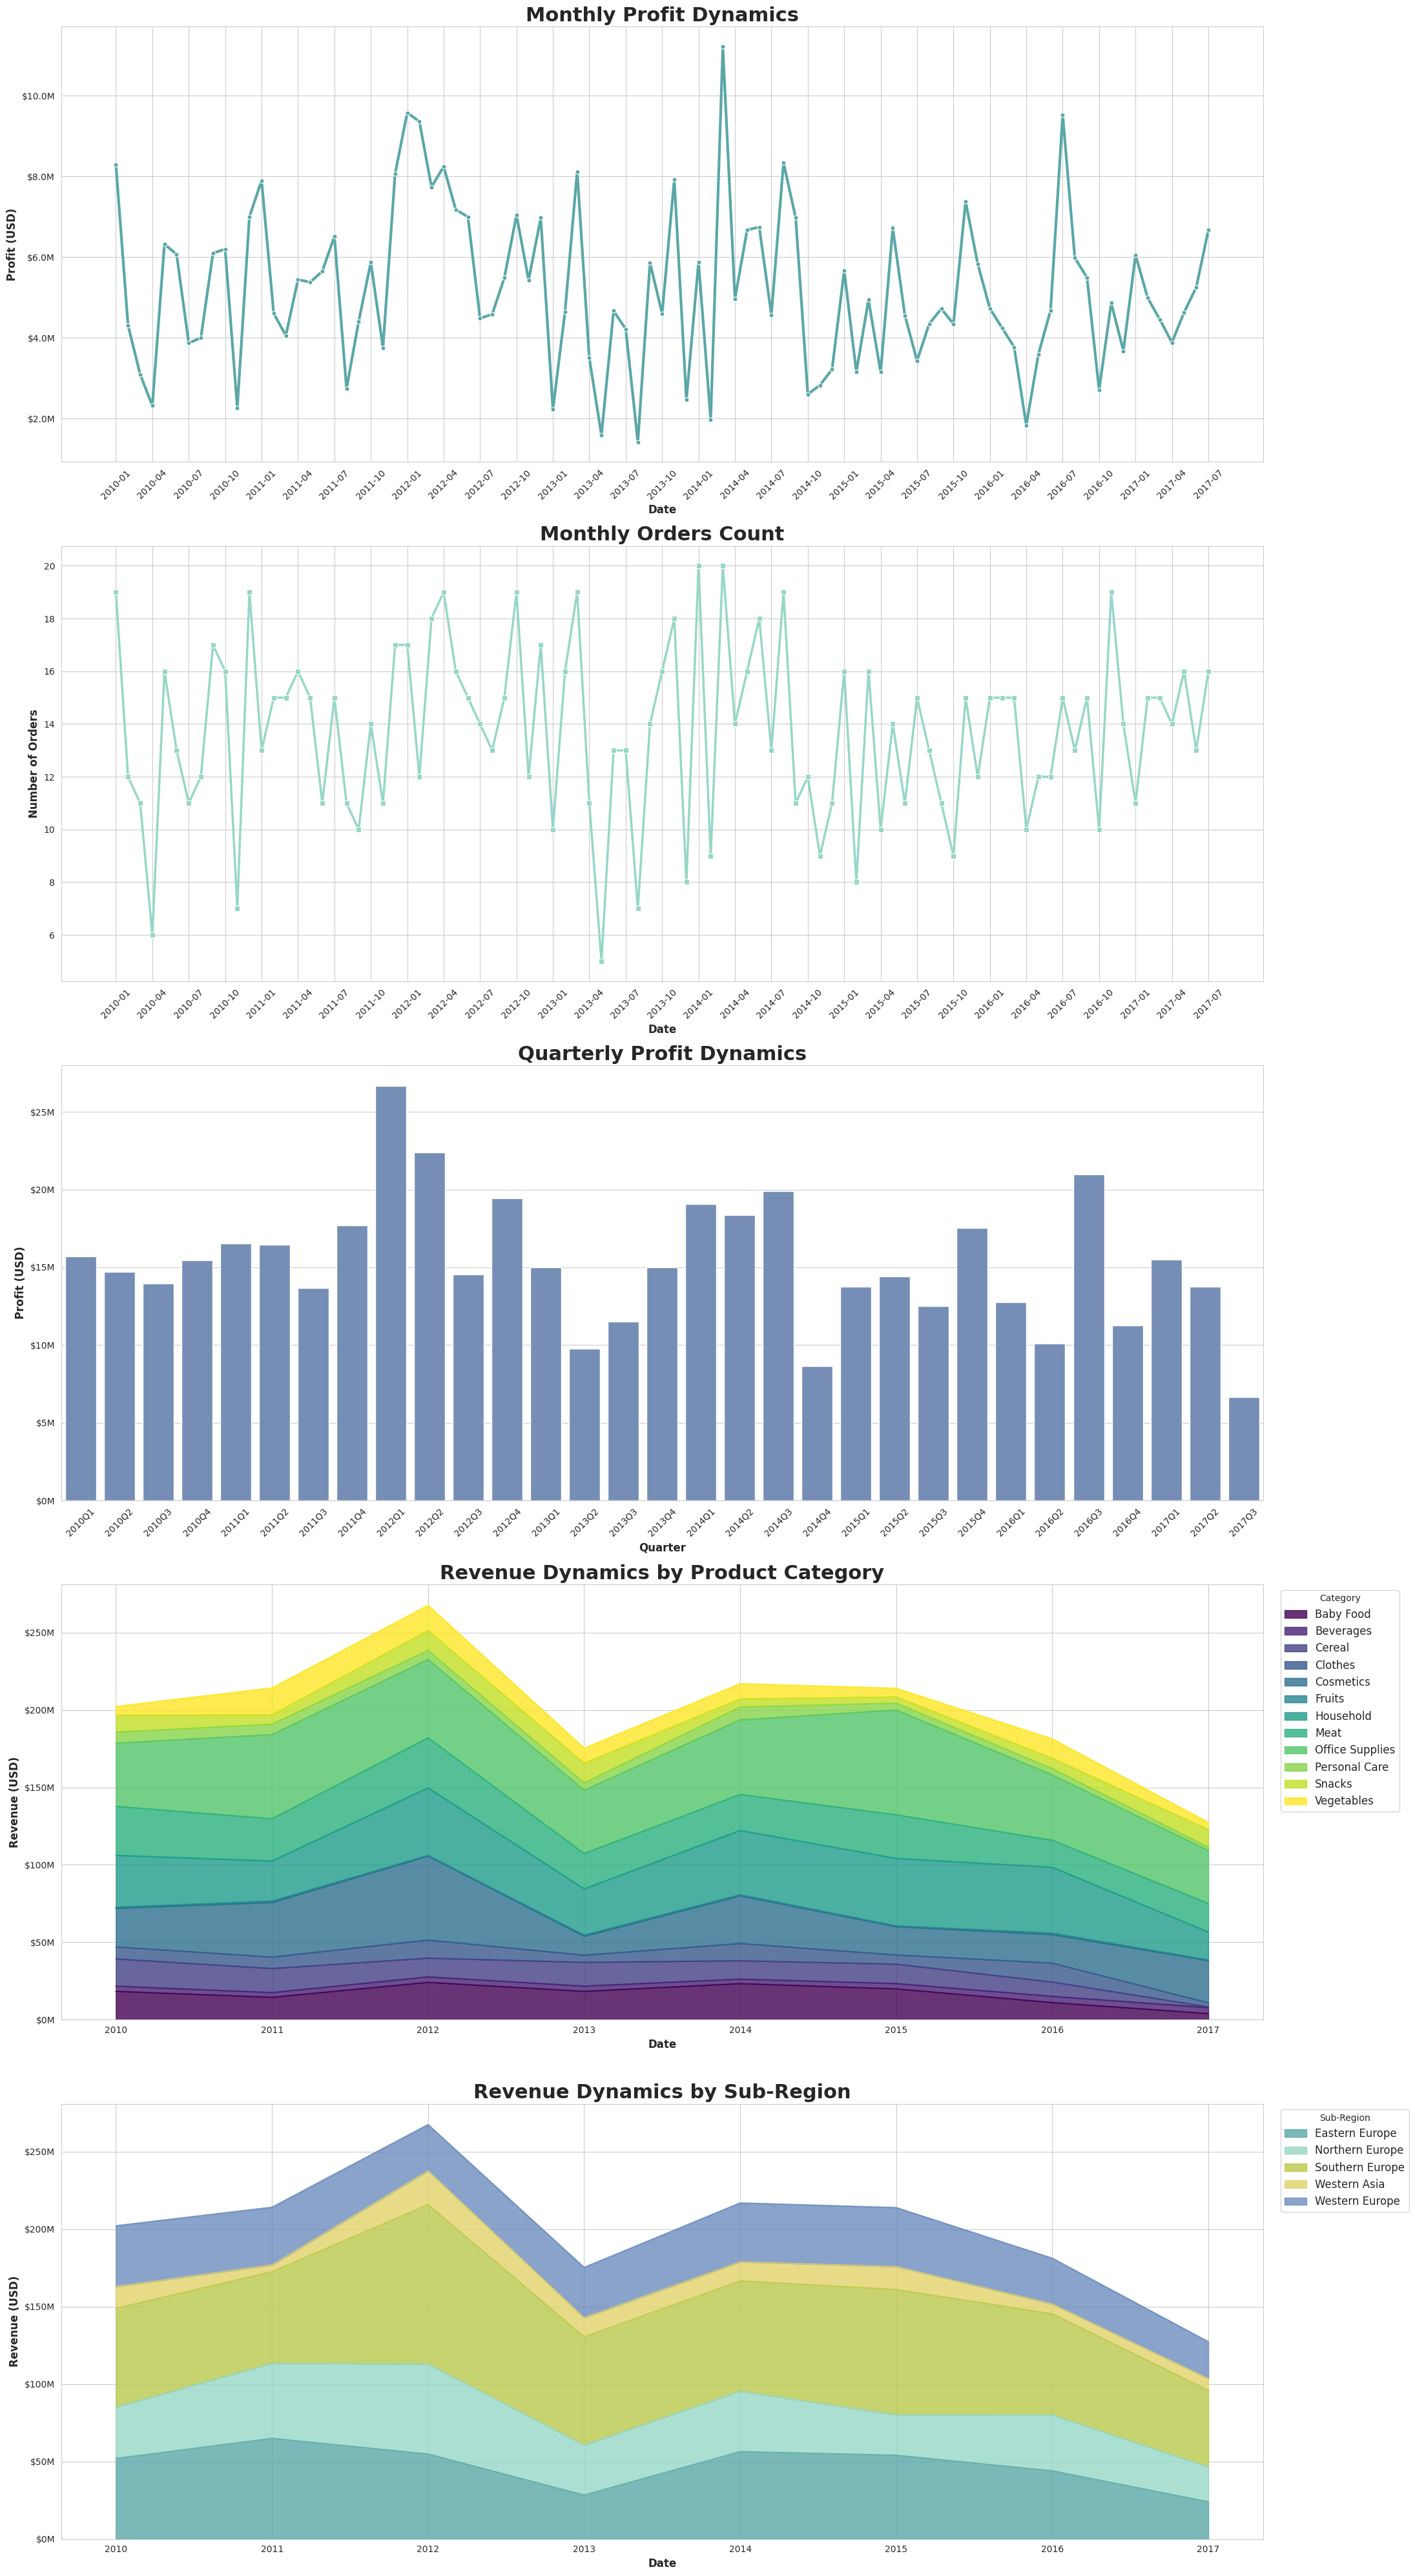

In [51]:
# Dashboard Visualization
fig, axes = plt.subplots(5, 1, figsize=(22, 40))
plt.subplots_adjust(hspace=0.4)

# Graph 1: Monthly Profit Dynamics Line Chart
sns.lineplot(data=monthly_main, x="month_year", y="profit", ax=axes[0],
             color=colors[0], linewidth=3, marker='o', markersize=5)
axes[0].set_title("Monthly Profit Dynamics", fontsize=22, fontweight="bold")
axes[0].set_xlabel("Date", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Profit (USD)", fontsize=12, fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))

# Show every 3rd month for readability
axes[0].set_xticks(axes[0].get_xticks()[::3])
axes[0].tick_params(axis='x', rotation=45)

# Graph 2: Monthly Orders Count Line Chart
sns.lineplot(data=monthly_main, x="month_year", y="order_id", ax=axes[1],
             color=colors[1], marker="s", markersize=6, linewidth=2.5)
axes[1].set_title("Monthly Orders Count", fontsize=22, fontweight="bold")
axes[1].set_xlabel("Date", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Number of Orders", fontsize=12, fontweight="bold")
axes[1].set_xticks(axes[1].get_xticks()[::3])
axes[1].tick_params(axis='x', rotation=45)

# Graph 3: Quarterly Profit Bar Chart
sns.barplot(data=quarterly_profit, x="quarter", y="profit", ax=axes[2],
            color=colors[4], legend=False)
axes[2].set_title("Quarterly Profit Dynamics", fontsize=22, fontweight="bold")
axes[2].set_xlabel("Quarter", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Profit (USD)", fontsize=12, fontweight="bold")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M"))
axes[2].tick_params(axis='x', rotation=45)

# Graph 4: Revenue by Product Category Stacked Area
cat_pivot = yearly_cat.pivot(index="year", columns="product_category", values="revenue").fillna(0)
cat_pivot.plot(kind="area", stacked=True, ax=axes[3], colormap="viridis", alpha=0.8)
axes[3].set_title("Revenue Dynamics by Product Category", fontsize=22, fontweight="bold")
axes[3].set_xlabel("Date", fontsize=12, fontweight="bold")
axes[3].set_ylabel("Revenue (USD)", fontsize=12, fontweight="bold")
axes[3].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M"))
axes[3].legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=12)

# Graph 5: Revenue by Sub-Region Stacked Area
sub_pivot = yearly_sub_region.pivot(index="year", columns="sub-region", values="revenue").fillna(0)
sub_pivot.plot(kind="area", stacked=True, ax=axes[4], color=colors, alpha=0.8)
axes[4].set_title("Revenue Dynamics by Sub-Region", fontsize=22, fontweight="bold")
axes[4].set_xlabel("Date", fontsize=12, fontweight="bold")
axes[4].set_ylabel("Revenue (USD)", fontsize=12, fontweight="bold")
axes[4].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M"))
axes[4].legend(title="Sub-Region", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

**Sales Dynamics Analysis**
- The company's profit and order count do not show a clear upward trend over the full period. Sales go up and down each year, with no stable growth. **The best year was 2012**, when quarterly profit reached its highest point (~\$25M per quarter). After 2012, profit dropped significantly and stayed lower.
- **Seasonality**: The monthly charts show high volatility - profit jumps up and down every month with no clear seasonal pattern.
- **Product Categories**: All categories follow the same general trend - peak in 2012, drop in 2013, partial recovery in 2014-2016. **Office Supplies, Household, and Clothes** are the largest contributors to profit at all times. **Fruits, Snacks, and Vegetables** remain very small throughout all years.
- **Regions**: **Western Europe and Southern Europe** dominate the profit at all times and follow the same rise-and-fall pattern as the overall business. **Western Asia** contributes a small but stable share every year.

####**3.9. Sales by Day of Week & Seasonality**

In [52]:
# Day of week
df["day_of_week"] = df["order_date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Profit & Orders by Day of Week
daily = df.groupby("day_of_week").agg({
    "profit": "sum",
    "order_id": "nunique"
}).reindex(day_order).reset_index()

# Profit by Day of Week & Category (heatmap)
day_cat = df.groupby(["day_of_week", "product_category"])["profit"].sum().unstack().reindex(day_order)

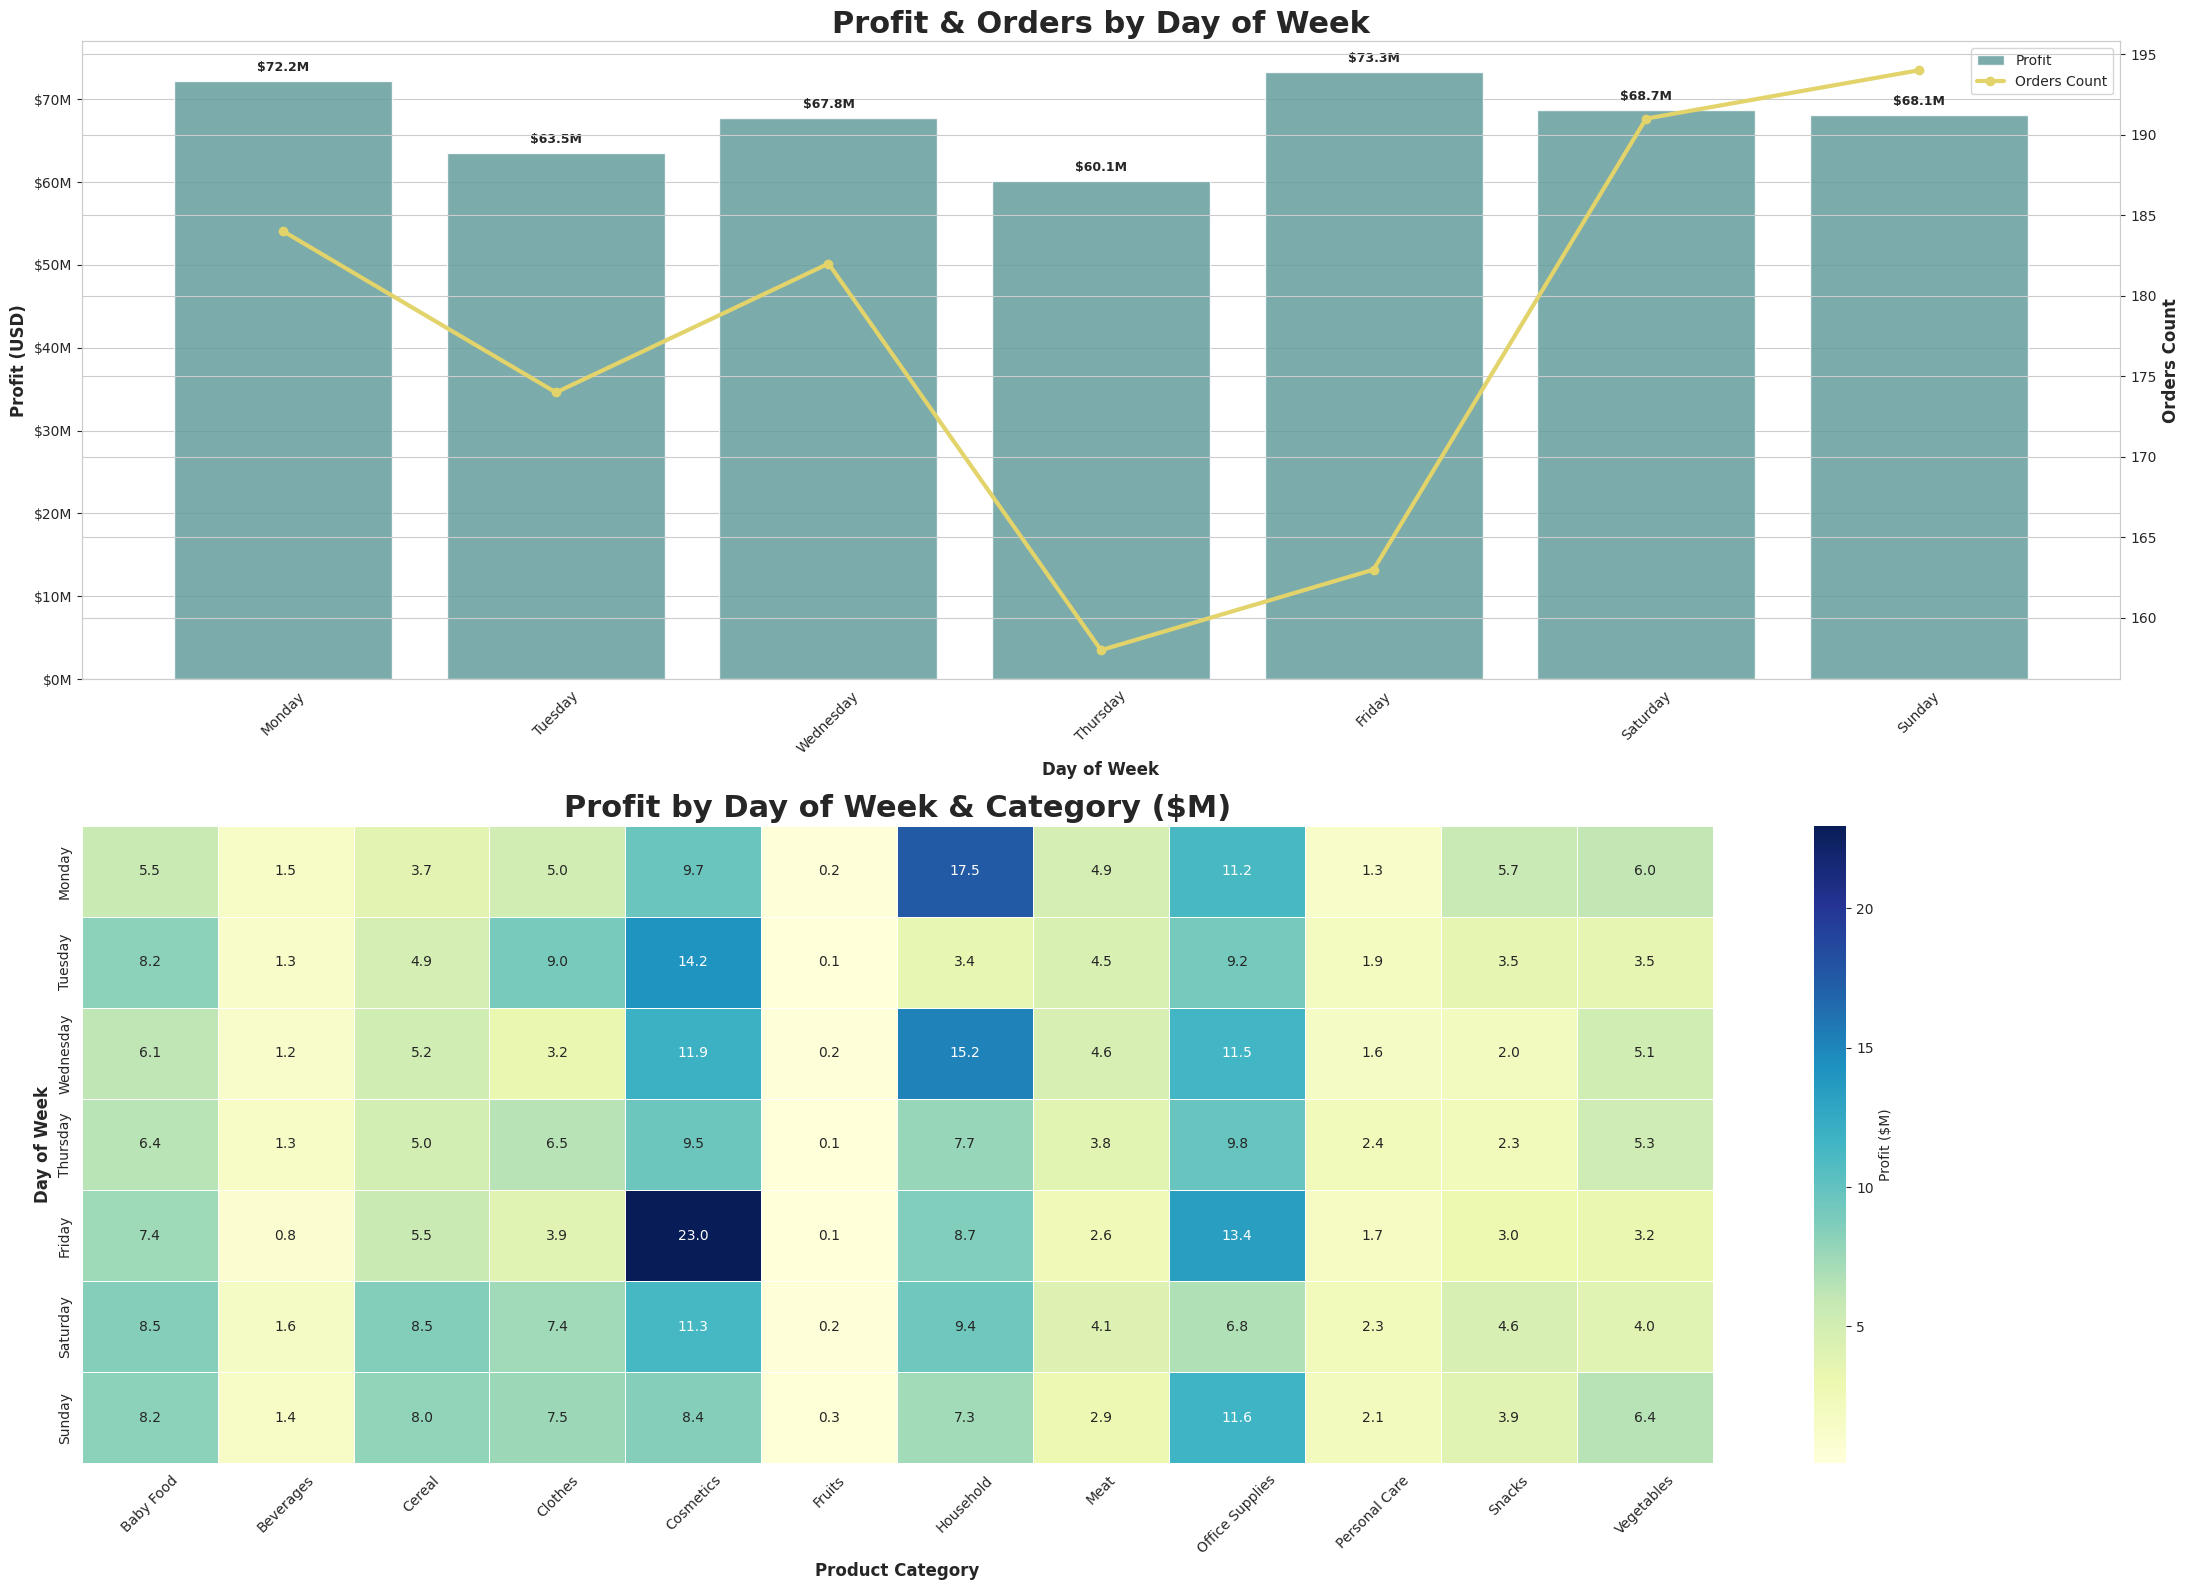

In [53]:
# Dashboard Visualization
fig, axes = plt.subplots(2, 1, figsize=(22, 16))
plt.subplots_adjust(wspace=0.4)

# Graph 1: Profit & Orders by Day of Week Twin Axes
ax1 = axes[0]
ax1_twin = ax1.twinx()

sns.barplot(data=daily, x="day_of_week", y="profit",
            ax=ax1, color=colors[0], label="Profit", alpha=0.85)
x_pos = range(len(daily))
ax1_twin.plot(x_pos, daily["order_id"],
              color=colors[3], marker="o", linewidth=3, label="Orders Count")

ax1.set_title("Profit & Orders by Day of Week", fontsize=22, fontweight="bold")
ax1.set_xlabel("Day of Week", fontsize=12, fontweight="bold")
ax1.set_ylabel("Profit (USD)", fontsize=12, fontweight="bold")
ax1_twin.set_ylabel("Orders Count", fontsize=12, fontweight="bold")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.0f}M"))
ax1.tick_params(axis="x", rotation=45)

for p in ax1.patches:
    ax1.annotate(f"${p.get_height()/1e6:.1f}M",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha="center", va="bottom", xytext=(0, 5),
                 textcoords="offset points", fontweight="bold", fontsize=9)

lines1, lbls1 = ax1.get_legend_handles_labels()
lines2, lbls2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbls1 + lbls2, loc="upper right", fontsize=10)

# Graph 2: Profit by Day of Week & Category Heatmap
sns.heatmap(day_cat / 1e6, ax=axes[1],
            cmap="YlGnBu", annot=True, fmt=".1f",
            linewidths=0.5, cbar_kws={"label": "Profit ($M)"})
axes[1].set_title("Profit by Day of Week & Category ($M)", fontsize=22, fontweight="bold")
axes[1].set_xlabel("Product Category", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Day of Week", fontsize=12, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Sales Analysis by Day of Week**
- **Profit** is relatively stable across all days of the week - the difference between the best day **(Friday, \$73.3M)** and the worst day **(Thursday, \$60.1M)** is not very large.
- **Orders count** drops significantly on **Thursday** (160 orders) and then grows on **Saturday and Sunday** (~192 orders). So weekends have more orders but not always more profit.
- **Heatmap Insights**
   - **Cosmetics** generates the highest profit on Friday (\$23.0M), which is much higher than other days.
   - **Household** performs best on Monday (\$17.5M) and Wednesday (\$15.2M), and drops on Tuesday (\$3.4M).
   - **Office Supplies** is strong on Friday (\$13.4M) and Monday (\$11.2M-11.5M range), which makes sense as these are typical business purchase days.
   - **Meat** and **Fruits** shows relatively low and stable numbers across all days with no clear peak.

In [54]:
# Profit by Month & Category
df["month"] = df["order_date"].dt.month
month_cat = df.groupby(["month", "product_category"])["profit"].sum().unstack()

# % of annual profit
month_cat_pct = month_cat / month_cat.sum() * 100

# Seasonality flag
seasonality = month_cat_pct.std().sort_values(ascending=False).reset_index()
seasonality.columns = ["product_category", "monthly_std"]
seasonality["is_seasonal"] = seasonality["monthly_std"] > 3.5

print(seasonality)

   product_category  monthly_std  is_seasonal
0           Clothes     4.332159         True
1            Fruits     3.981190         True
2         Baby Food     3.526420         True
3         Cosmetics     3.415659        False
4            Snacks     3.268761        False
5         Beverages     3.114647        False
6              Meat     2.919815        False
7            Cereal     2.878314        False
8   Office Supplies     2.742266        False
9     Personal Care     2.718058        False
10        Household     2.157402        False
11       Vegetables     1.976340        False


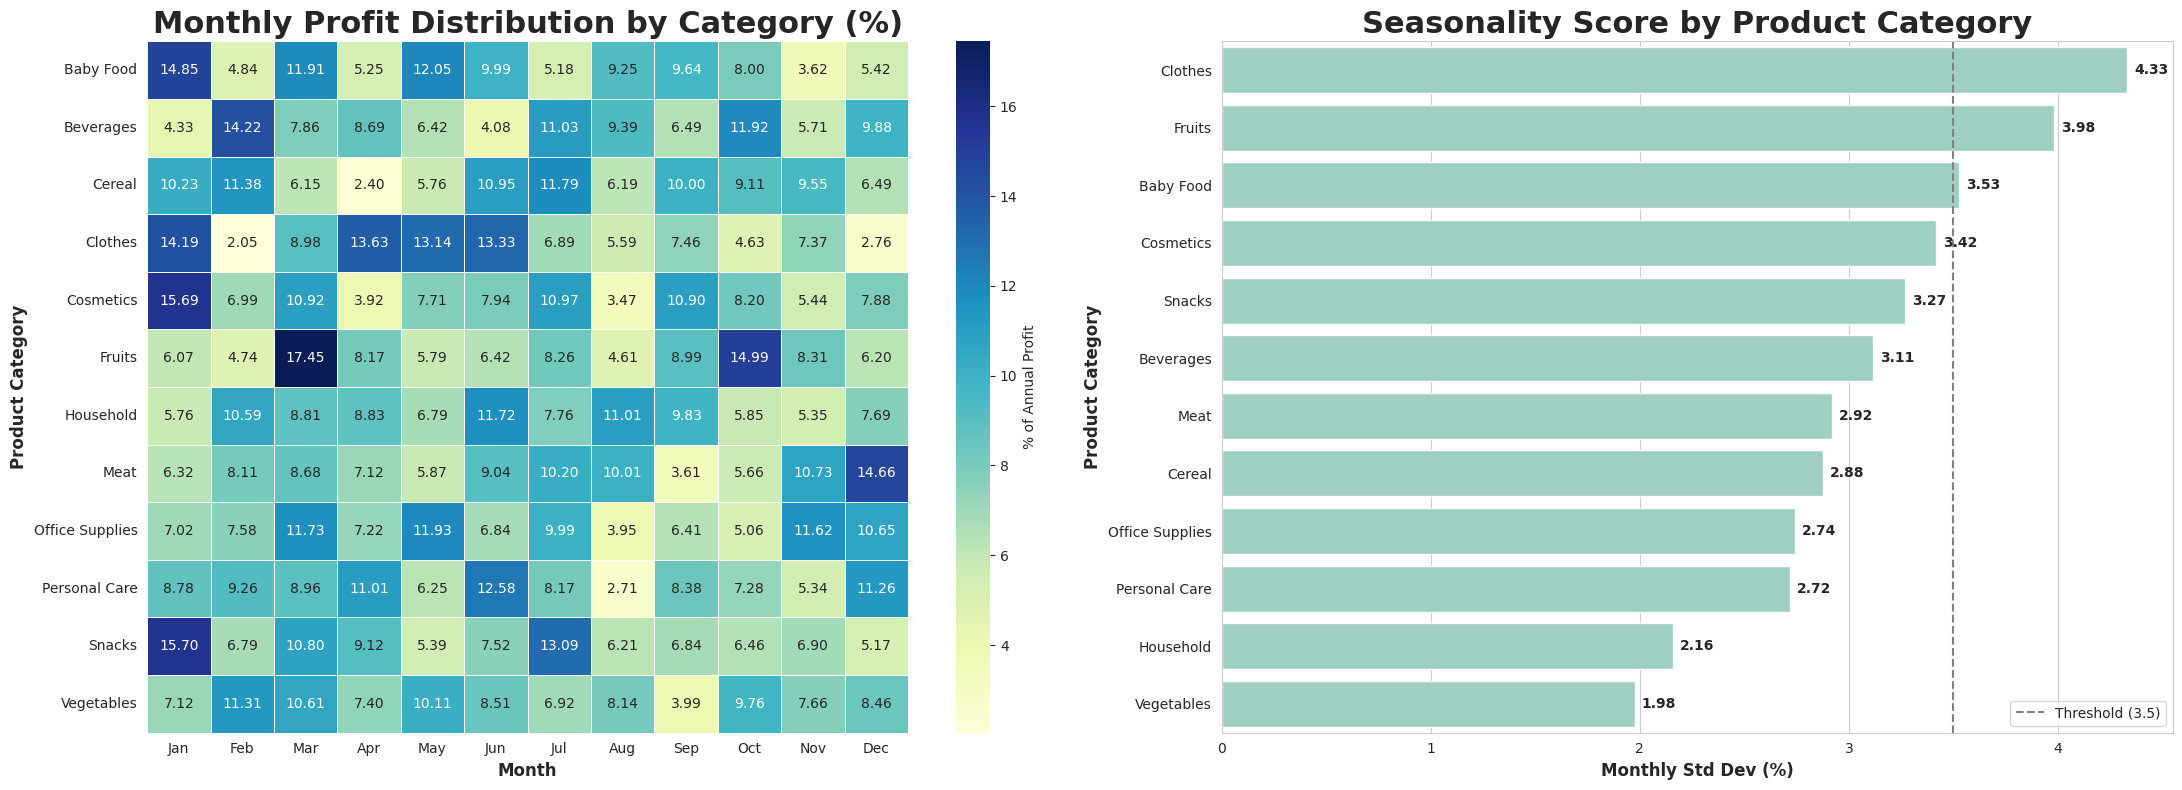

In [55]:
# Dashboard Visualization
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
plt.subplots_adjust(wspace=0.4)

# Graph 1: Monthly Profit % by Category Heatmap
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_cat_pct_plot = month_cat_pct.copy()
month_cat_pct_plot.index = month_labels

sns.heatmap(month_cat_pct_plot.T, ax=axes[0],
            cmap="YlGnBu", annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "% of Annual Profit"})
axes[0].set_title("Monthly Profit Distribution by Category (%)", fontsize=22, fontweight="bold")
axes[0].set_xlabel("Month", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Product Category", fontsize=12, fontweight="bold")

# Graph 2: Seasonality Score Bar Chart
seasonal_bars = sns.barplot(data=seasonality, x="monthly_std", y="product_category",
                             ax=axes[1], color=colors[1])
axes[1].axvline(x=3.5, color="gray", linestyle="--", linewidth=1.5, label="Threshold (3.5)")
axes[1].set_title("Seasonality Score by Product Category", fontsize=22, fontweight="bold")
axes[1].set_xlabel("Monthly Std Dev (%)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Product Category", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)

for p in seasonal_bars.patches:
    axes[1].annotate(f"{p.get_width():.2f}",
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha="left", va="center", xytext=(5, 0),
                     textcoords="offset points", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

**Seasonality Analysis by Product Category**
- **Seasonal Product Categories**:
   - **Clothes** has the highest seasonality score (4.33%). Looking at the heatmap, it peaks strongly in January (14.19%) and May (13.14%), and drops very low in February (2.05%) and December (2.76%).
   - **Fruits** is also seasonal (3.98%). It has a very high spike in March (17.45%) and October (14.99%), with low months in between.
   - **Baby Food** is just above the threshold (3.53%). It peaks in January (14.85%) and May (12.05%), with a notable low in November (3.62%).
- **Non-Seasonal Categories**:
   - **Vegetables** (1.98%) and **Household** (2.16%) are the most stable categories-— profit is spread almost evenly across all 12 months.
   - **Office Supplies, Personal Care, Cereal, and Meat** all have low scores between 2.7-2.9%.

##**Business Intelligence Report**
1. **Overall Business Performance**

The company operates at significant scale - 1.59B dollars in revenue, 473.7M dollars in profit, and 1,246 orders across 45 countries. The average order value of \$1.28M indicates this is a B2B-oriented business dealing in large bulk transactions rather than individual consumer sales. The overall profit margin stands at 29.63%, which is healthy for a trading company.

2. **Product Portfolio**

The portfolio shows extreme imbalance. Clothes delivers a 67.2% margin while Meat delivers only 13.6% . This is the single most important strategic finding.
High-priority categories: Clothes, Cereal, Vegetables, Cosmetics. These should receive the most investment and marketing focus.
Problem categories: Office Supplies generates the highest revenue (\$378.7M) but only 19.4% margin, meaning most of that revenue is consumed by costs.

3. **Geographic Concentration**

This is the most serious structural weakness in the business. Europe accounts for 94.7% of all profit (\$448.6M), with Asia contributing only 5.3%. There are no other regions represented at all.
Within Europe, the top 10 countries are all small European nations - Andorra, Malta, San Marino, Macedonia - rather than large economies.
This level of geographic concentration represents extreme business risk. Expansion into Americas, Africa, or broader Asia is a survival necessity.

4. **Sales Channels**

The 50/50 split between Online (49.7%) and Offline (50.3%). However, the order count trend from 2010-2017 shows no growth - volumes fluctuate between 70-95 orders per year with no upward trajectory.
The channel balance is a strength, but the absence of growth needs new customer acquisition strategies.

5. **Logistics**

Average shipping time of 23-27 days across all categories and regions is extremely high. Personal Care is the best performer at 20.4 days - which is still nearly 3 weeks. Hungary averages 32.6 days, which is operationally unacceptable for most product types.
The analysis confirms that shipping speed has almost zero correlation with profit (r = 0.0607). This means customers are not paying premium prices for faster delivery, and the company is not losing profit by shipping slowly. However, long shipping times likely affect customer satisfaction and repeat purchase behavior.

6. **Day-of-Week Patterns**

Friday generates the highest profit (\$73.3M total) driven largely by Cosmetics. Household shows an unusual Tuesday collapse.
Schedule targeted promotions and sales outreach to align with these patterns - Cosmetics campaigns on Thursdays to capture Friday buying, Household campaigns at the start of the week.

7. **Seasonality**

Three categories show meaningful seasonality: Clothes peaks in January and May, Fruits spikes in March and October, Baby Food peaks in January and May. The remaining 9 categories show remarkably stable year-round demand.
For seasonal categories, the company should pre-position inventory 4-6 weeks before peak months given the 23-27 day shipping baseline.

### **Key Strategic Priorities Summary**
Our main problems are: doing too much business only in Europe, big differences in product profits, no sales growth in 7 years, and slow shipping in Eastern Europe.

To improve our business, we need to focus on four main areas:
1. **Find New Markets (Global Expansion):**
- Since 94.7% of our profit comes from Europe, we are highly vulnerable. We must reduce this risk by entering larger markets in the Americas, Africa, or Asia.
2. **Focus on Profitable Products (Product Strategy):**
- We need to reallocate marketing budgets to high-margin categories like Clothes, Cereal, and Cosmetics. Conversely, we must cut costs or raise prices for low-margin items like Office Supplies and Meat.
3. **Improve Shipping (Logistics):**
- Delivery to Eastern Europe takes too long (up to 32 days). We must partner with faster shipping providers and pre-stock inventory ahead of seasonal sales peaks.
4. **Get New Customers (Sales Growth):**
- Order volumes have stagnated since 2012. We need to launch aggressive customer acquisition campaigns and time our promotions to match customers' weekly buying habits.